In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import plotly.graph_objects as go
import json

In [2]:
from src.datasets.datamodules import DataModule
from src.my_model.transformer import *

In [3]:
config = {
    "min_hits": 3,
    "min_pt": 0.5,
    "max_pt": 10,
    "keep_secondaries": False,
    "max_abs_eta": 1,
    # "max_abs_eta": 4,
}
config["sort_by_radius"] = True
config["cut_scattered"] = True

In [4]:
config["input_variables"] = ["tx", "ty", "tz"]
# config["input_variables"] = ["tr", "tphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tz"]
# config["input_variables"] = ["tx", "ty", "tz", "pT_circle_estimate"]


# config["output_variables"] = ['pT', 'pz']
config["output_variables"] = ["qopT", "pz"]
# config["output_variables"] = ["qpT", "pz"]

dataset_name = "TrackML_kaggle"
dataset_name = "TrackML_zenodo"
# dataset_name = "TrackML_zenodo_full"
if dataset_name == "TrackML_kaggle":
    dataset_dir = Path("Data/Tml/train_1")
elif dataset_name == "TrackML_zenodo":
    dataset_dir = Path("Data/TrackML/training_part01")
else:
    dataset_dir = Path("Data/TrackML/full_dataset")

In [5]:
import pandas as pd

# Creating a structured dataframe for the models
model_data = [
    (["tx", "ty", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_155", None, "Models/TrackML/version_154"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_168", "Models/TrackML/version_195", "Models/TrackML/version_192"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_206", None, "Models/TrackML/version_205"),
    (["tr", "tphi", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_160", None, "Models/TrackML/version_159"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_162", None, "Models/TrackML/version_161"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_191", None, "Models/TrackML/version_177"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_203", None, "Models/TrackML/version_201"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_193", "Models/TrackML/version_198", "Models/TrackML/version_196"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_169", "Models/TrackML/version_194", "Models/TrackML/version_178"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_279", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_483", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_492", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_497", None, None),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_487", None, None),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_204", None, "Models/TrackML/version_202"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_249", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_315", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_392", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_432", None, None),
    (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_460", None, None),
    (["tx", "ty", "tz", "pT_circle_estimate"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
]

# Creating a DataFrame
model_df = pd.DataFrame(
    model_data,
    columns=[
        "input_variables",
        "dataset_name",
        "output_variables",
        "mse_dir",
        "mse_inv_dir",
        "qloss_dir",
    ],
)
model_df["input_variables"] = model_df["input_variables"].apply(tuple)
model_df["output_variables"] = model_df["output_variables"].apply(tuple)

In [6]:
# Function to retrieve available models based on input configuration, dataset name, and DataFrame
def get_available_models(model_df, config_input, dataset_name, config_output):
    config_input = tuple(config_input)
    config_output = tuple(config_output)

    filtered_df = model_df[
        (model_df["input_variables"] == config_input)
        & (model_df["dataset_name"] == dataset_name)
        & (model_df["output_variables"] == config_output)
    ]

    if not filtered_df.empty:
        model_dict = {
            "mse_dir": filtered_df.iloc[0]["mse_dir"],
            "mse_inv_dir": filtered_df.iloc[0]["mse_inv_dir"],
            "qloss_dir": filtered_df.iloc[0]["qloss_dir"],
        }
        return {
            k: v for k, v in model_dict.items() if v is not None
        }  # Remove None values
    else:
        return {}


available_models = get_available_models(
    model_df, config["input_variables"], dataset_name, config["output_variables"]
)
print(available_models)

{'mse_dir': 'Models/TrackML/version_487'}


In [7]:
models_dir = {
    "MSE": Path(available_models["mse_dir"]),
}
if "qloss_dir" in available_models:
    models_dir["QLoss"] = Path(available_models["qloss_dir"])
if "mse_inv_dir" in available_models:
    models_dir["MSE_inv"] = Path(available_models["mse_inv_dir"])

In [8]:
# Define models. (Assumes that p_pred_mse_list and p_pred_qloss_list are defined externally.)
models = {
    "MSE": {
        "color": "skyblue",
        "cmap": "Blues",
        "label": "MSE",
        "marker": "o",
    },
}
if "QLoss" in models_dir:
    models["QLoss"] = {
        "color": "coral",
        "cmap": "Reds",
        "label": "Quantile Loss",
        "marker": "^",
    }

In [9]:
variable_labels = {
    "tx": "tx",
    "ty": "ty",
    "tz": "tz",
    "tr": "tr",
    "tphi": r"t\varphi",
    "dphi": r"d\varphi",
    "pT": "p_T",
    # "qopT": r"\frac{q}{p_T}",
    "qopT": "q/p_T",
    "qpT": "q*p_T",
    "pz": "p_z",
    "pT_circle_estimate": "p_T (circle estimate)",
}

# variable_filenames is a reverse mapping of variable_labels
variable_filenames = {v: k for k, v in variable_labels.items()}

variable_units = {
    "tx": "mm",
    "ty": "mm",
    "tz": "mm",
    "tr": "mm",
    "tphi": "rad",
    "dphi": "rad",
    "pT": "GeV",
    "qopT": "1/GeV",
    "qpT": "GeV",
    "pz": "GeV",
}

In [10]:
title_suffix = ""

# Add input and output variables to the title suffix
title_suffix += (
    f" ((${'$, $'.join([variable_labels[var] for var in config['input_variables']])}$)"
)
title_suffix += r" $ \to $ "
title_suffix += (
    f"(${'$, $'.join([variable_labels[var] for var in config['output_variables']])}$))"
)

In [11]:
output_dir = Path("Results/TrackML/")

input_variables = "".join(config["input_variables"]).replace("t", "")

output_variables = "_".join(config["output_variables"])

experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}_full_dataset"
# experiment_name += "_bacth_size_2048"
# experiment_name += "_e_32_h_16"
# experiment_name += "_eta_4"
# experiment_name += "_huber"
# experiment_name += "_huber_resolution_e_32_h_2"
# experiment_name += "_huber_resolution_huber_e_32_h_2"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_no_scat_{dataset_name}_e_128_h_2_no_droupout"

output_dir = output_dir / experiment_name

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True, parents=True)

In [12]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type="tml",
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

─────────────────────────────────────────────────── Tml Dataset ───────────────────────────────────────────────────

In [13]:
from src.analysis.utils import (
    get_model_checkpoint_path,
    get_config,
    validate_model_config,
    var_to_pT,
    compute_likelyhood,
    compute_track_resolution,
    get_smallest_confidence_interval,
)

In [14]:
mse_config = get_config(models_dir["MSE"])
validate_model_config(mse_config, config, dataset_dir=dataset_dir, criterion="mse", allow_other_datasets=dataset_name == "TrackML_zenodo_full")
if "QLoss" in models_dir:
    qloss_config = get_config(models_dir["QLoss"])
    validate_model_config(
        qloss_config, config, dataset_dir=dataset_dir, criterion="qloss-0.5"
    )

In [15]:
# Load models
for model in models_dir:
    if model not in models:
        print(f"Skipping {model} model (not defined in models)")
        continue
    print(f"Loading {model} model")
    ml_model_path = get_model_checkpoint_path(models_dir[model])
    # _instantiator is a function that is called to instantiate the model
    # Here the models have been trained using cli raising an error if _instantiator is not None
    ml_model = TrackFormer.load_from_checkpoint(
        checkpoint_path=ml_model_path, _instantiator=None, metric="sign",
    )
    ml_model.eval().to("cpu")
    models[model]["model"] = ml_model

Loading MSE model


In [16]:
# Full dataset test: 17 min 09 s (23 804 batches)
# Full dataset eta 4 test: 52 min 34 s (85 627 batches)
p_true_list = []
n_hits_list = []

bad_tracks_q = []
bad_tracks_mse = []
bad_tracks_mse_pT = []
bad_tracks_mse_pT_sign = []
worst_tracks_mse_pT = []

abs_relative_error_model_max = {model: 0 for model in models}
abs_relative_error_model_max_pT = {model: 0 for model in models}

for model in models:
    models[model]["data_list"] = []

with torch.no_grad():
    for i, (input, mask, target) in enumerate(tqdm(tl)):

        # Transformers
        p_true = target
        p_true_list.extend(p_true.tolist())
        n_hits_list.extend(mask.sum(dim=1).tolist())

        for model in models:
            ml_model = models[model]["model"]
            p_pred_model = ml_model(input, mask=mask)
            models[model]["data_list"].extend(p_pred_model.tolist())

            error_model = p_pred_model - p_true
            relative_error_model = error_model / p_true
            abs_relative_error_model = np.abs(relative_error_model)

            # print(ml_model.metric(p_pred_model, p_true))

            if model != "MSE":
                continue

            if (abs_relative_error_model > 10).any():
                mask_ = (abs_relative_error_model > 10).any(axis=1)
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            # Do only for pT
            # if config["output_variables"][0] != "pT":
            #     continue

            abs_relative_error_model_max[model] = max(abs_relative_error_model[:, 0].max(), abs_relative_error_model_max[model])

            if abs_relative_error_model[:, 0].max() == abs_relative_error_model_max[model]:
                mask_ = abs_relative_error_model[:, 0] == abs_relative_error_model_max[model]
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                worst_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            if abs_relative_error_model[:, 0].max() > 1:
                mask_ = abs_relative_error_model[:, 0] > 1
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            if (np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])).any():
                mask_ = np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse_pT_sign.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

0it [00:00, ?it/s]

In [17]:
if 'pT_circle_estimate' in config["input_variables"]:
    from src.my_model.benchmarks import CircleFit

    p_true_list = []
    n_hits_list = []

    bad_tracks_q = []
    bad_tracks_mse = []
    bad_tracks_mse_pT = []
    bad_tracks_mse_pT_sign = []

    circle_pt_list = []

    abs_relative_error_model_max = {model: 0 for model in models}
    abs_relative_error_model_max_pT = {model: 0 for model in models}

    for model in models:
        models[model]["data_list"] = []

    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):

            # Transformers
            p_true = target
            p_true_list.extend(p_true.tolist())
            n_hits_list.extend(mask.sum(dim=1).tolist())

            # PT estimate is the last variable of the input
            pt_estimate = input[:, :, -1]
            input = input[:, :, :-1]
            # print(f"{input.shape = }")
            # print(f"{pt_estimate.shape = }")
            # pt_estimate = input[:, -1]
            # input = torch.tensor(input[:, :-1], dtype=torch.float32)

            for model in models:
                ml_model = models[model]["model"]
                p_pred_model = ml_model(input, mask=mask)
                models[model]["data_list"].extend(p_pred_model.tolist())

                error_model = p_pred_model - p_true
                relative_error_model = error_model / p_true
                abs_relative_error_model = np.abs(relative_error_model)

                # print(ml_model.metric(p_pred_model, p_true))

                if model != "MSE":
                    continue

                if (abs_relative_error_model > 10).any():
                    mask_ = (abs_relative_error_model > 10).any(axis=1)
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                # Do only for pT
                # if config["output_variables"][0] != "pT":
                #     continue

                abs_relative_error_model_max[model] = max(abs_relative_error_model[:, 0].max(), abs_relative_error_model_max[model])

                if abs_relative_error_model[:, 0].max() > 1:
                    mask_ = abs_relative_error_model[:, 0] > 1
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                if (np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])).any():
                    mask_ = np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse_pT_sign.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))
            cf = CircleFit()
            print("second fit")
            # print(input)
            # print(input.shape)
            # print(input.dim())
            # Remove the masked points
            points = []
            for particle_index, particle in enumerate(input):
                particle_hit_mask = mask[particle_index]
                valid_particle_hits = particle[particle_hit_mask]
                points.append(valid_particle_hits)
                # points.append([hit for hit_index, hit in enumerate(particle) if mask[particle_index, hit_index]])


            # points = input
            r = cf.fit(points).tolist()
            pt_fit = np.array(r) * 1.0 * 2 * 299_792_458 / 1e9 / 1000
            pt_fit = pt_fit.tolist()
            circle_pt_list.extend(pt_fit)

            print(pt_estimate.tolist())
            print(pt_fit)





    # f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true{}"
    # f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true"
    # print(f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true")
    # print(cf.fit(thing.unsqueeze(0)))
    # print(cf.params)

In [18]:
# Skip the cell if not relevant:
if 'pT_circle_estimate' in config["input_variables"]:
    p_t_true = 1/np.abs(np.array(p_true_list)[:, 0])
    p_t_true = np.array(p_true_list)[:, 0]
    x = (np.array(circle_pt_list)-p_t_true)/p_t_true * 100
    symlog_bins = np.logspace(np.min(np.log10(np.abs(x))), np.max(np.log10(np.abs(x))), 100)
    symlog_bins = np.concatenate((-symlog_bins[::-1], [0], symlog_bins))
    plt.hist(x, bins=symlog_bins)
    # plt.hist(, bins=
    # print((np.array(circle_pt_list)-p_t_true)/p_t_true * 100)
    plt.xscale("symlog")
    plt.show()
    print(f"{np.mean(np.abs(x)) = }")
    print(f"{np.std(np.abs(x)) = }")
    print(f"{np.mean(x) = }")
    print(f"{np.std(x) = }")
    print(f"{np.median(x) = }")
    print(f"{np.min(np.abs(x)) = }")
    print(f"{np.max(np.abs(x)) = }")

In [19]:
# plot the CDF of the relative error
if 'pT_circle_estimate' in config["input_variables"]:
    x = np.sort(np.abs(x))
    y = np.arange(len(x)) / len(x)
    plt.plot(x, y)
    plt.xscale("log")
    plt.grid()
    # Add Y ticks for every 0.1
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.show()

In [20]:
print("Max relative error for pT")
for model in models:
    print(f"{model}: {abs_relative_error_model_max[model]}")

Max relative error for pT
MSE: 2.7854578495025635


In [21]:
import torch

def test_permutation_invariance(model, input_tensor, mask):

    max_difference_ = 0
    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):
            # Get the original prediction
            original_prediction = model(input, mask=mask)

            # Shuffle the hits in the input tensor
            shuffled_input_tensor = input.clone()
            shuffled_mask = mask.clone()
            for i in range(shuffled_input_tensor.size(0)):
                # Set a shuffle variable to shuffle the hits
                shuffle_variable = torch.randperm(shuffled_input_tensor.size(1))
                shuffled_input_tensor[i] = shuffled_input_tensor[i][shuffle_variable]
                shuffled_mask[i] = mask[i][shuffle_variable]

            # Get the prediction after shuffling
            shuffled_prediction = model(shuffled_input_tensor, mask=shuffled_mask)

            # Compare the original and shuffled predictions
            difference = torch.abs(original_prediction - shuffled_prediction)
            max_difference = torch.max(difference).item()
            if max_difference > max_difference_:
                max_difference_ = max_difference

    print(f"Max difference between original and shuffled predictions: {max_difference_}")

    return max_difference_

# # Test the permutation invariance for the MSE model
# max_diff_mse = test_permutation_invariance(models["MSE"]["model"], input, mask)
# print(f"Max difference for MSE model: {max_diff_mse}")

# # Test the permutation invariance for the QLoss model
# if "QLoss" in models:
#     max_diff_qloss = test_permutation_invariance(models["QLoss"]["model"], input, mask)
#     print(f"Max difference for QLoss model: {max_diff_qloss}")

In [22]:
import torch

def test_variable_permutation_invariance(model):

    max_difference_ = 0
    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):
            # Get the original prediction
            original_prediction = model(input, mask=mask)

            # Shuffle the hit variables in the input tensor
            shuffled_input_tensor = input.clone()
            for i in range(shuffled_input_tensor.size(0)):
                # Set a shuffle variable to shuffle the hit variables
                shuffle_variable = torch.randperm(shuffled_input_tensor.size(2))
                shuffled_input_tensor[i] = shuffled_input_tensor[i][:, shuffle_variable]

            # Get the prediction after shuffling
            shuffled_prediction = model(shuffled_input_tensor, mask=mask)

            # Compare the original and shuffled predictions
            difference = torch.abs(original_prediction - shuffled_prediction)
            max_difference = torch.max(difference).item()
            if max_difference > max_difference_:
                max_difference_ = max_difference

    print(f"Max difference between original and shuffled predictions: {max_difference_}")

    return max_difference_

# # Test the permutation invariance for the MSE model
# max_diff_mse = test_variable_permutation_invariance(models["MSE"]["model"])
# print(f"Max difference for MSE model: {max_diff_mse}")

# # Test the permutation invariance for the QLoss model
# if "QLoss" in models:
#     max_diff_qloss = test_permutation_invariance(models["QLoss"]["model"], input, mask)
#     print(f"Max difference for QLoss model: {max_diff_qloss}")

In [23]:
import numpy as np
from src.analysis.visualization import (
    view_trajectory,
    sync_plot_limits,
)

In [24]:
i = 3 # 3
print(bad_tracks_mse_pT[i][:][0])
view_trajectory(bad_tracks_mse_pT[i][1])

([2.7854578495025635, -0.7471134662628174], [-0.5206044912338257, -1.064579963684082])


In [25]:
i = -1
print(len(bad_tracks_mse_pT_sign))
print(bad_tracks_mse_pT_sign[i][:][0])
view_trajectory(bad_tracks_mse_pT_sign[i][1])

4
([-1.3429467678070068, 0.01423936802893877], [0.12876614928245544, 1.1027599573135376])


In [26]:
for i in range(len(bad_tracks_mse_pT_sign)):
    # print(bad_tracks_mse_pT_sign[i][:][0][1])
    print(1/bad_tracks_mse_pT_sign[i][:][0][1][0], (bad_tracks_mse_pT_sign[i][:][1].sum(axis=1) != 0).sum())

-8.780171835751618 tensor(11)
-1.2513798603159714 tensor(3)
-9.449209078237354 tensor(11)
7.766016189600005 tensor(14)


In [27]:
i = 5
print(bad_tracks_mse[i][:][0])
view_trajectory(bad_tracks_mse[i][1])

([0.035278961062431335, -17.701473236083984], [0.8453397154808044, 0.0005101939896121621])


In [28]:
thing = bad_tracks_mse[i][1][(bad_tracks_mse[i][1] != 0).any(dim=1)][:, :2]

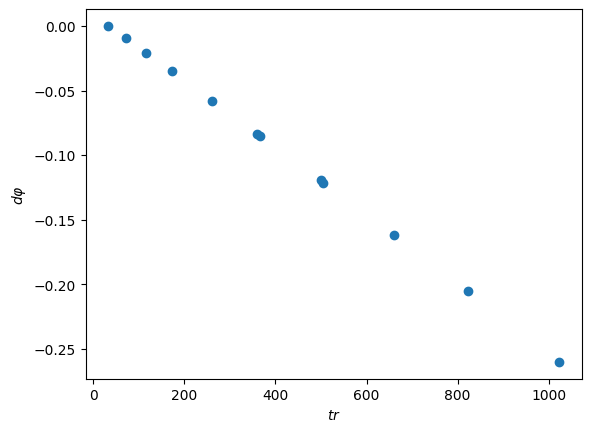

In [29]:
plt.scatter(thing[:, 0], thing[:, 1])
plt.xlabel(f"${variable_labels[config['input_variables'][0]]}$")
plt.ylabel(f"${variable_labels[config['input_variables'][1]]}$")
plt.show()

In [30]:
from src.my_model.benchmarks import CircleFit


cf = CircleFit()


# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true{}"
# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true"
print(f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true")
print(cf.fit(thing.unsqueeze(0)))
print(cf.params)

circle pred: 2285265.219 	 true
tensor([2285265.2189], dtype=torch.float64)
[array([-9.86601347e+01, -2.28526524e+06,  2.28526522e+06])]


/home/couthures/Bureau/TrackParameters/TrackFormer/src/my_model/benchmarks.py:51: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1729111943459/work/torch/csrc/utils/tensor_new.cpp:278.)



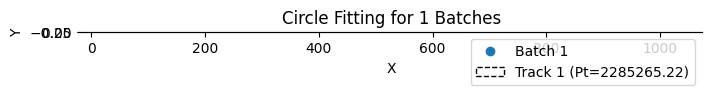

In [31]:
cf.plot()

In [32]:
bad_tracks_mse[i][0][1]

[0.8453397154808044, 0.0005101939896121621]

In [33]:
# Reload the module
from importlib import reload
import src.analysis.visualization as visualization
reload(visualization)
from src.analysis.visualization import (
    plot_err_vs_n_hits,
    plot_pi_true_vs_pred,
    plot_pi_error_distributions,
    plot_pi_rel_resolutions,
    plot_2d_histogram,
    plot_pi_relative_error_distributions,
    plot_pi_error_distributions_p,
    plot_pi_relative_error_distributions_low_pt_1_2,
)

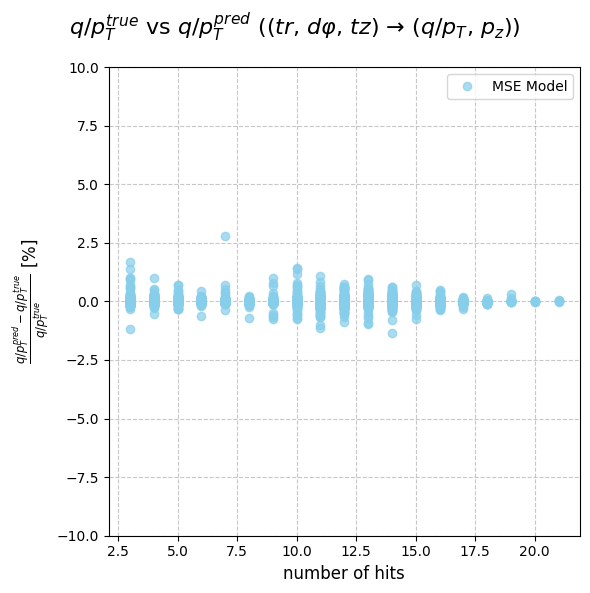

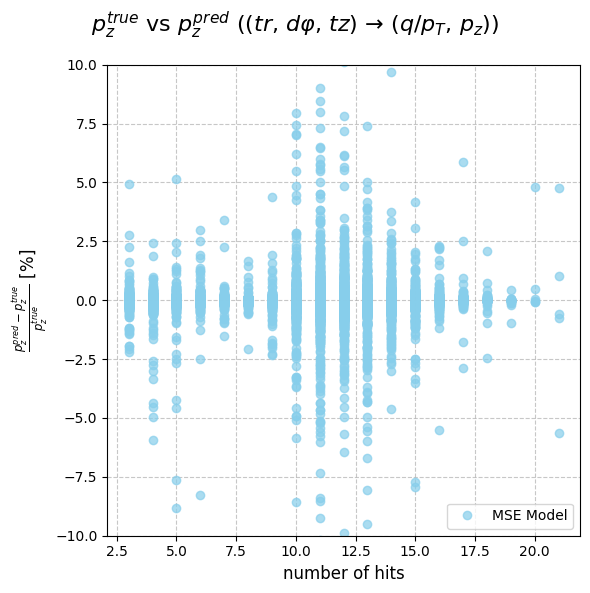

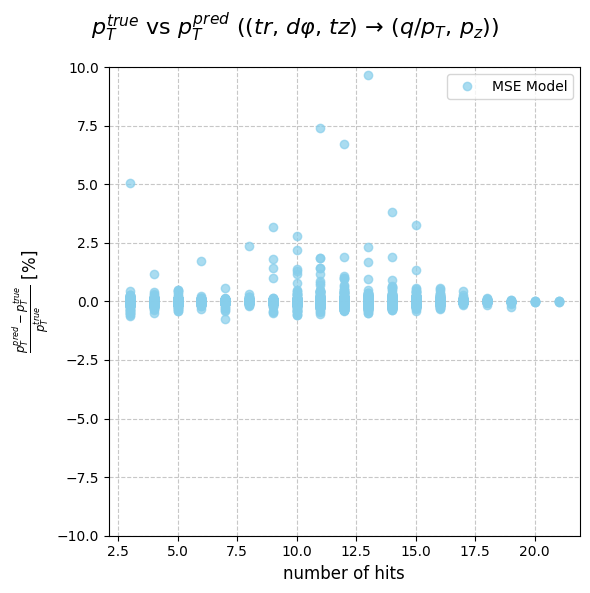

In [34]:
plot_err_vs_n_hits(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    n_hits_list=n_hits_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    # variable_labels,
    low_pt=False,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_err_vs_n_hits(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        n_hits_list=n_hits_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

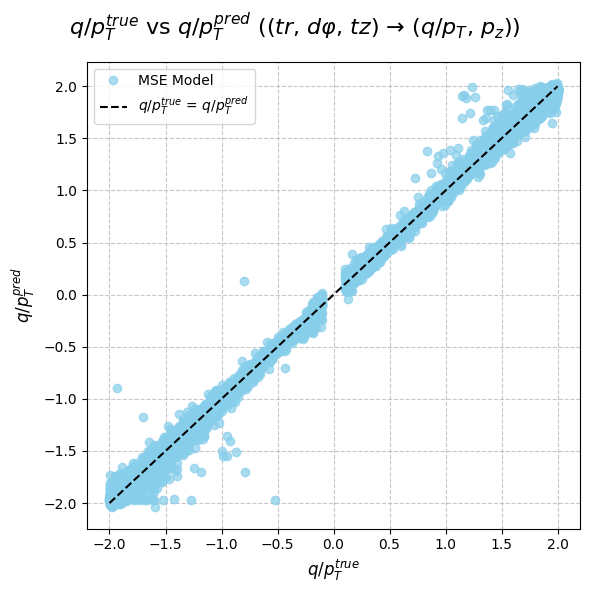

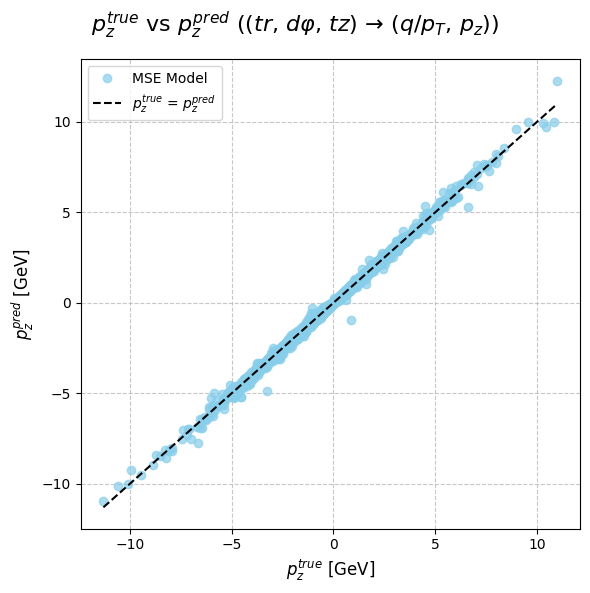

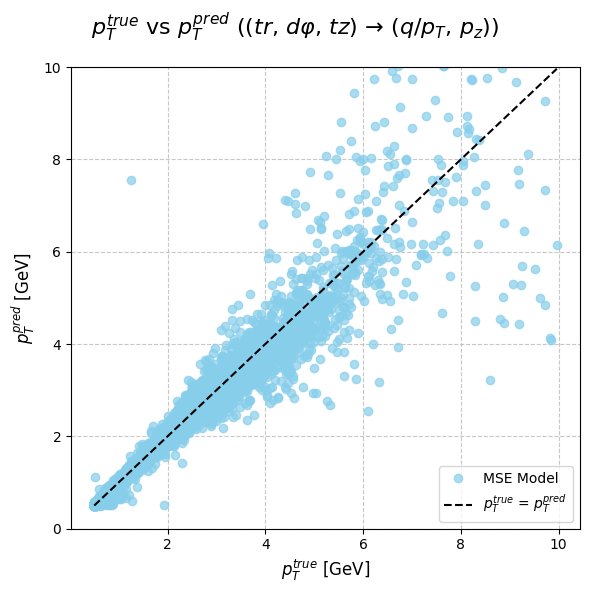

In [35]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_true_vs_pred(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

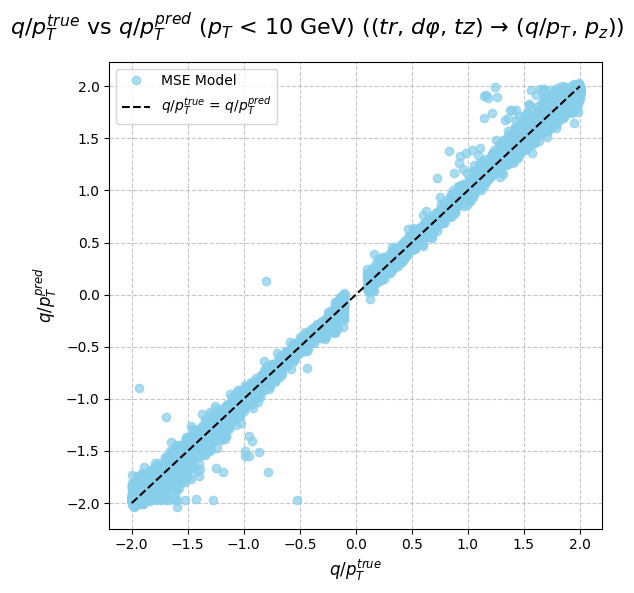

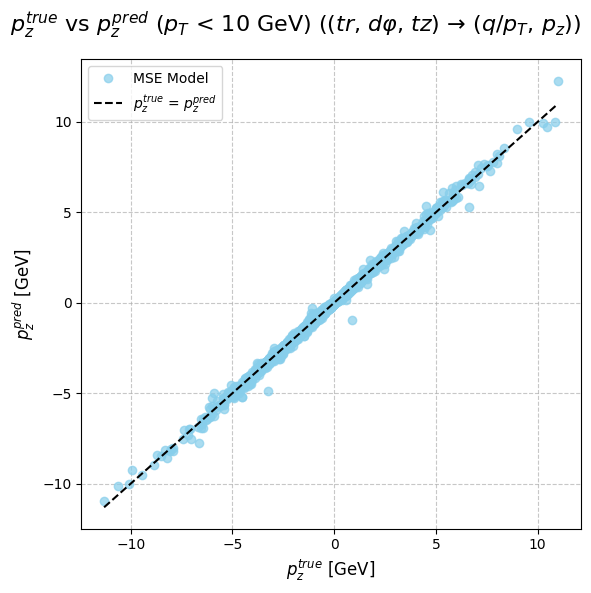

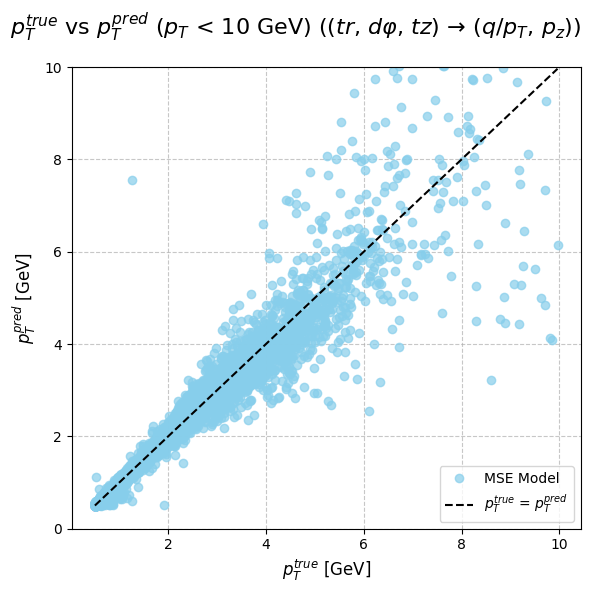

In [36]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    low_pt=True,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_true_vs_pred(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        low_pt=True,
    )

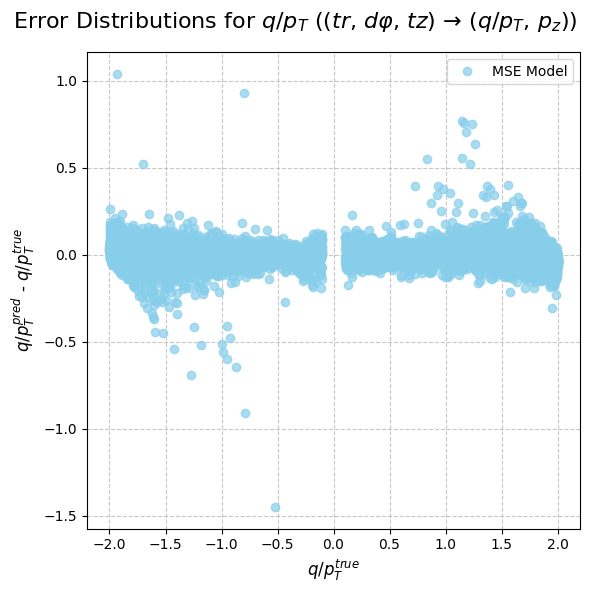

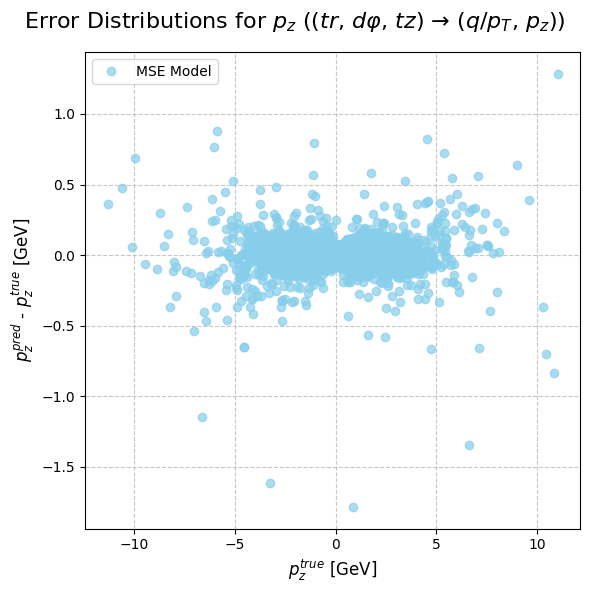

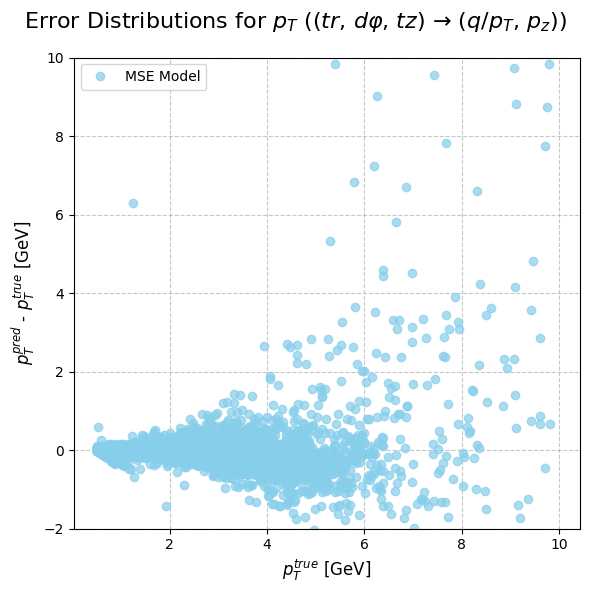

In [37]:
plot_pi_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



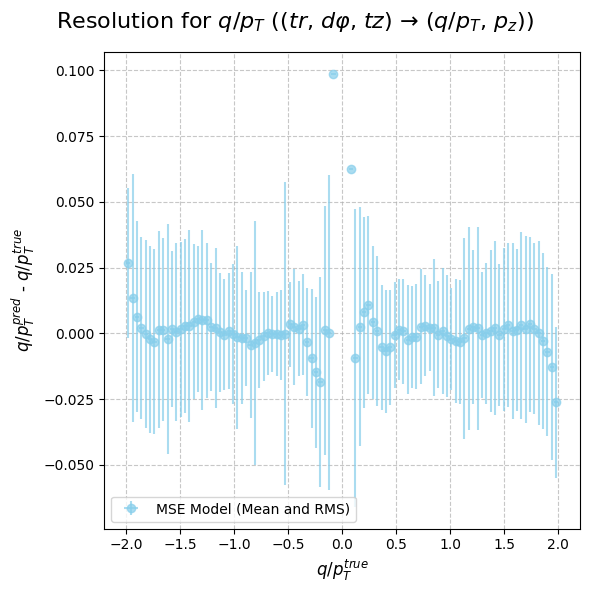

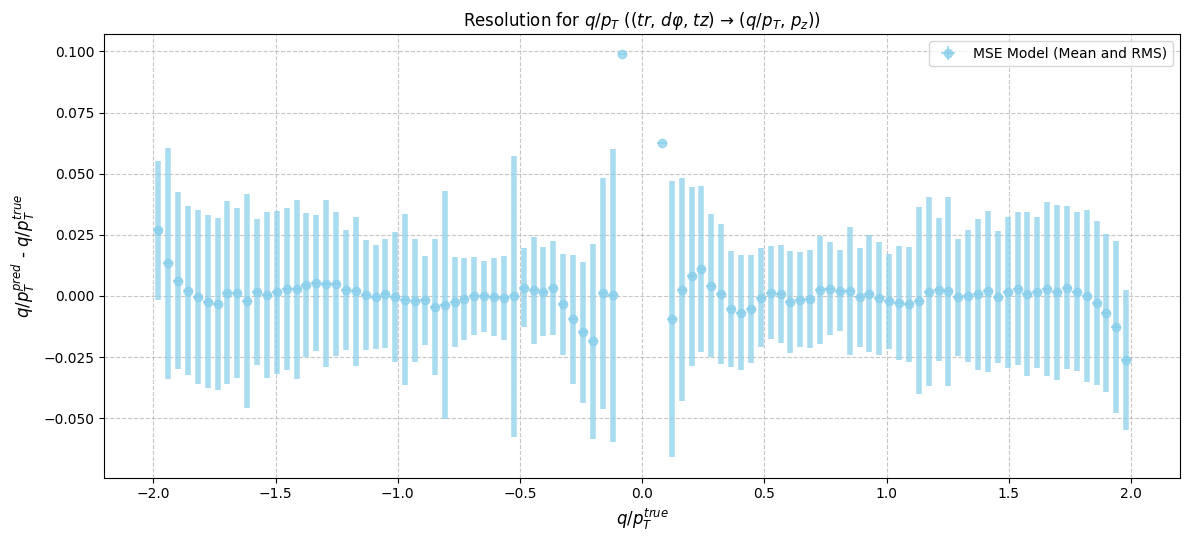

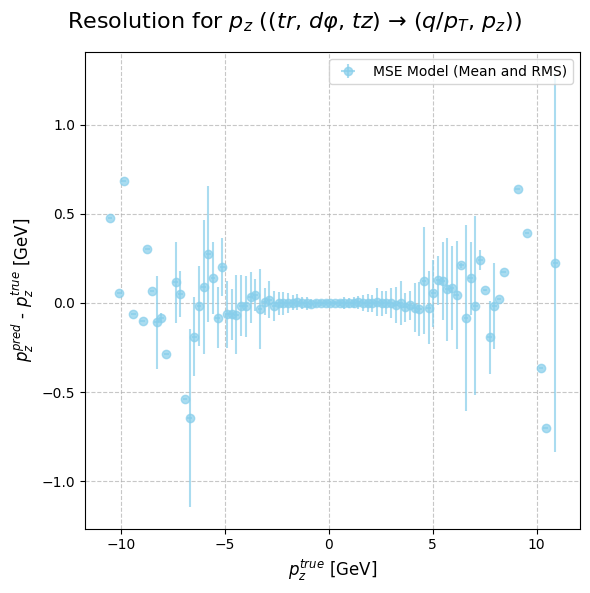

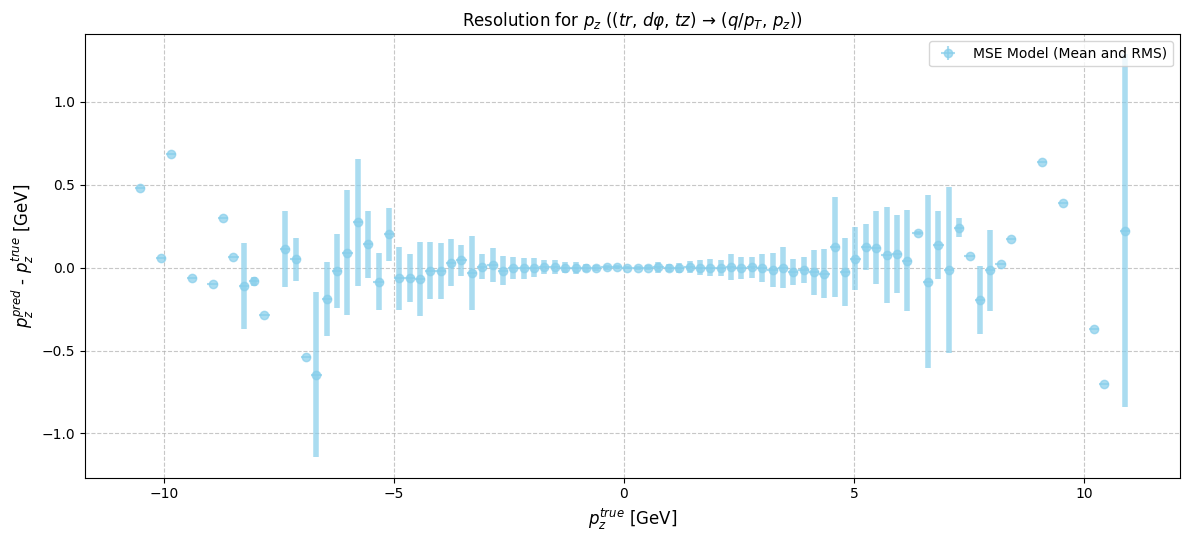

[ 0  1  2  4  6  8 10]


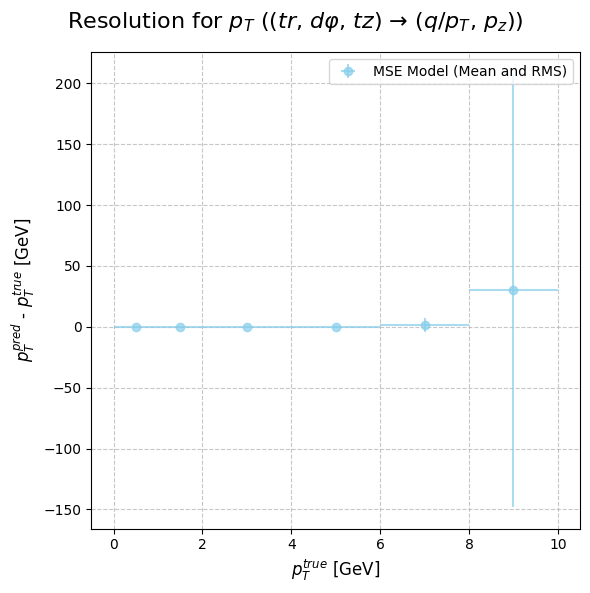

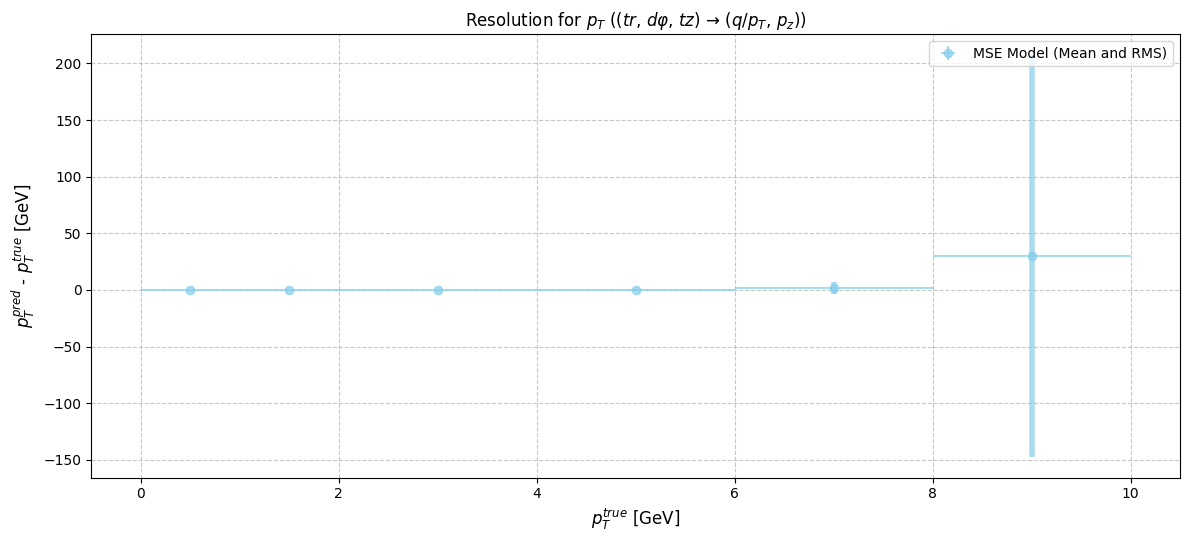

In [38]:
def plot_pi_resolutions(target_labels, pruning=False):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )

        title = f"Resolution for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = f"{pred_label} - {true_label}" + (
            " [GeV]" if var.startswith("p") else ""
        )
        filename = f"resolution_{variable_filenames[var]}.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_values), max(pi_true_values), 100)
        if var == "p_T":
            bins = np.logspace(
                np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
            )
            bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            print(bins)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if var == "p_T":
                pi_pred_values = var_to_pT(
                    values=pi_pred_values,
                    from_var=config["output_variables"][var_index],
                )

            errors = pi_pred_values - pi_true_values
            model_data[model_name] = errors

        # Loop over each model.
        model_bins = {}
        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_values) & (pi_true_values <= upper_bound)
            for model_name, model_info in models.items():
                if not pruning:
                    errors_bin = model_data[model_name][sel]
                    model_bin_mean, model_bin_std = np.mean(errors_bin), np.std(errors_bin)
                else:
                    pi_pred_values = np.array(model_info["data_list"])[:, var_index]
                    if var == "p_T":
                        pi_pred_values = var_to_pT(
                            values=pi_pred_values,
                            from_var=config["output_variables"][var_index],
                        )

                    errors_bin_pruned, removed_outliers_bin = compute_track_resolution(
                        pi_true_values[sel], pi_pred_values[sel]
                    )

                    if len(pi_true_values[sel]) == 0:
                        outlier_ratio = np.inf
                    else:
                        outlier_ratio = len(removed_outliers_bin) / len(pi_true_values[sel])

                    print(f"Fraction of tracks identified as outliers by model {model_name}: {outlier_ratio:.4%} for bin {(lower_bound, upper_bound)}")

                    model_bin_mean, model_bin_std = np.mean(errors_bin_pruned), np.std(errors_bin_pruned)


                model_bins.setdefault(model_name, []).append(
                    (model_bin_mean, model_bin_std)
                )

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # Loop over each model.
        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]

            plt.subplot(1, len(models), model_index)

            plt.errorbar(
                bin_centers,
                bin_counts,
                yerr=bin_std,
                xerr=(bins[1:] - bins[:-1]) / 2,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()
        
        if len(models) > 1:
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        else:
            plt.tight_layout()
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"resolution_{variable_filenames[var]}_one_plot.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename
        bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]
            if model_index == 1:
                xerr = (bins[1:] - bins[:-1]) / 2
                x = bin_centers
            elif model_index == 2:
                shift = bin_sizes * 0.0
                xerr_low = bin_sizes / 2 + shift
                xerr_high = bin_sizes / 2 - shift
                xerr_high[xerr_high < 0] = 0
                xerr = [xerr_low, xerr_high]
                x = bin_centers + shift

            errorbar_obj = plt.errorbar(
                x,
                bin_counts,
                yerr=bin_std,
                xerr=xerr,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            if model_index == 1:
                errorbar_obj[-1][1].set_linewidth(
                    4
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines
            elif model_index == 2:
                # Use dashed lines for y error bars
                # https://stackoverflow.com/questions/22995797/can-matplotlib-errorbars-have-a-linestyle-set
                errorbar_obj[-1][1].set_linestyle(
                    "--"
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title(title)
        # Specify in the legend that vertical error bars are rms of the distribution
        plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_resolutions(target_labels=["p_T"])

Fraction of tracks identified as outliers by model MSE: 4.0000% for bin (-1.9999938011169434, -1.9595902038343025)
Fraction of tracks identified as outliers by model MSE: 2.4838% for bin (-1.9595902038343025, -1.9191866065516616)
Fraction of tracks identified as outliers by model MSE: 2.0833% for bin (-1.9191866065516616, -1.8787830092690208)
Fraction of tracks identified as outliers by model MSE: 1.9190% for bin (-1.8787830092690208, -1.8383794119863799)
Fraction of tracks identified as outliers by model MSE: 3.6055% for bin (-1.8383794119863799, -1.797975814703739)
Fraction of tracks identified as outliers by model MSE: 2.2222% for bin (-1.797975814703739, -1.7575722174210981)
Fraction of tracks identified as outliers by model MSE: 1.5842% for bin (-1.7575722174210981, -1.7171686201384573)
Fraction of tracks identified as outliers by model MSE: 2.2634% for bin (-1.7171686201384573, -1.6767650228558164)
Fraction of tracks identified as outliers by model MSE: 3.0527% for bin (-1.676765

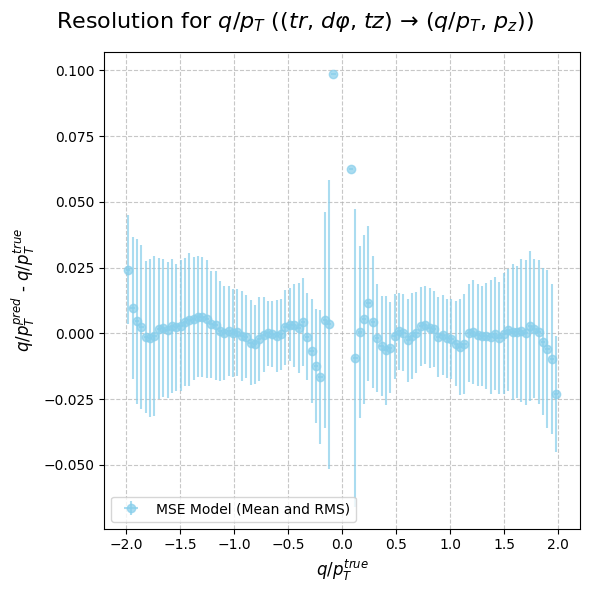

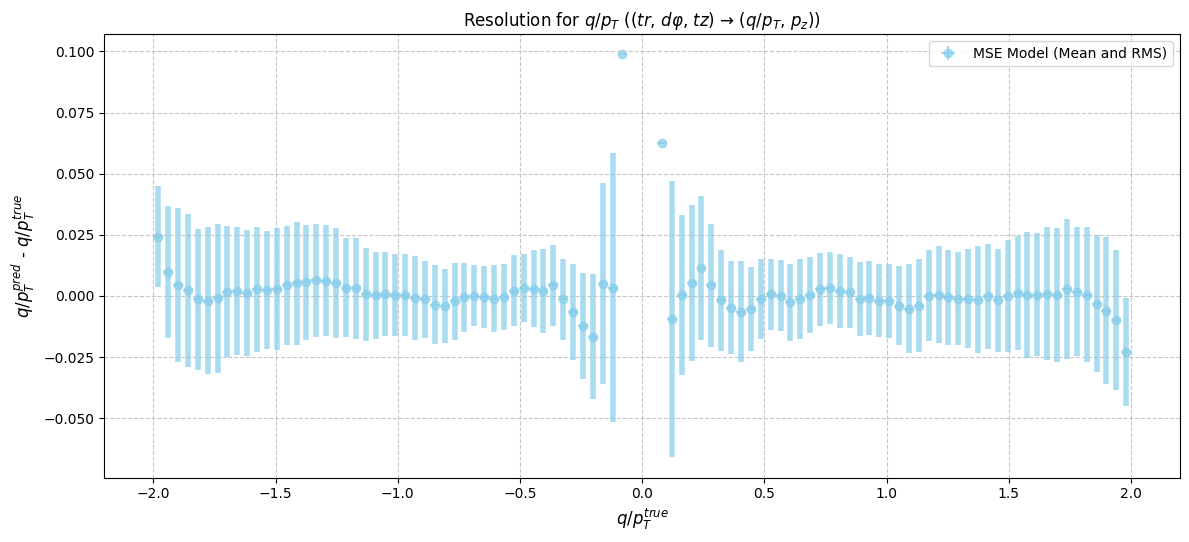

Fraction of tracks identified as outliers by model MSE: inf% for bin (-11.307600021362305, -11.082214162807272)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-11.082214162807272, -10.85682830425224)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-10.85682830425224, -10.631442445697207)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-10.631442445697207, -10.406056587142174)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-10.406056587142174, -10.180670728587142)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-10.180670728587142, -9.95528487003211)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.95528487003211, -9.729899011477075)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-9.729899011477075, -9.504513152922042)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.504513152922042, -9.27912729

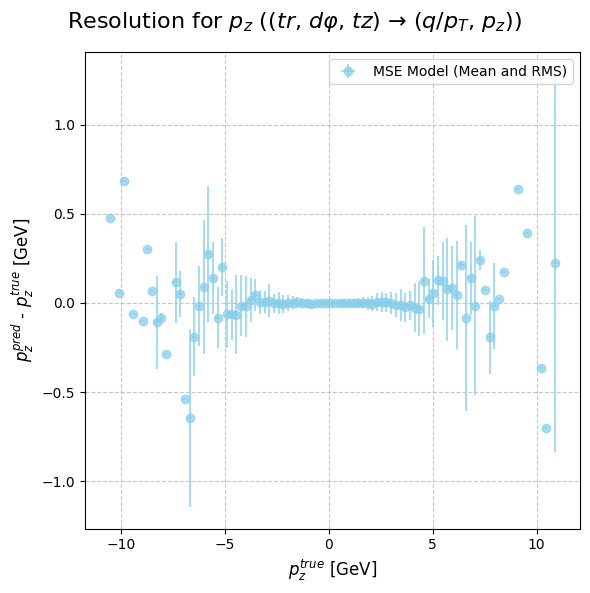

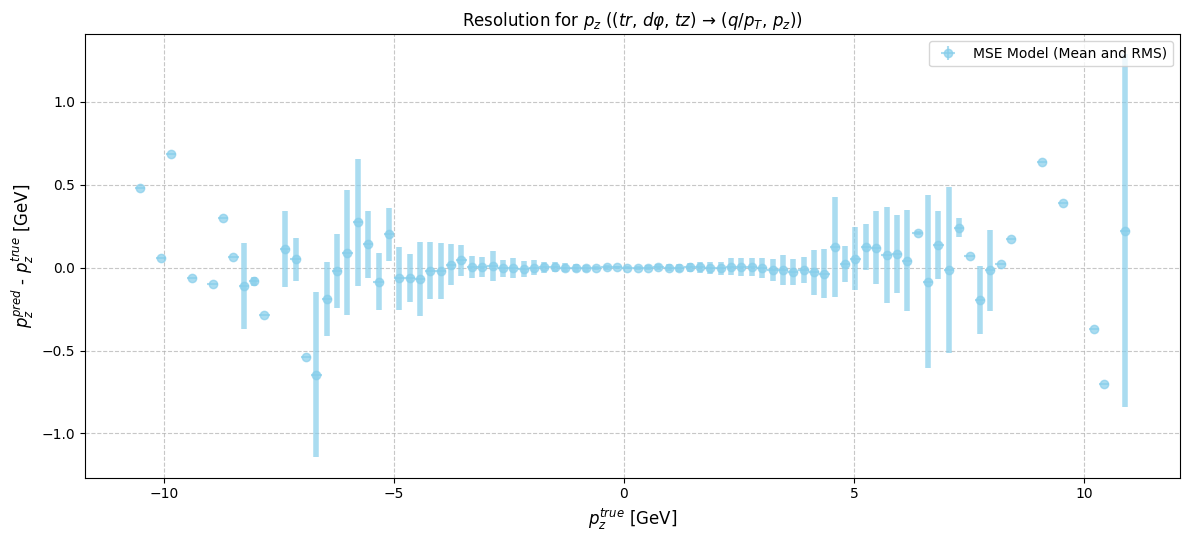

[ 0  1  2  4  6  8 10]
Fraction of tracks identified as outliers by model MSE: 2.4824% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 3.7636% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: 5.0257% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: 5.8722% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: 10.5634% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: 9.0909% for bin (8, 10)


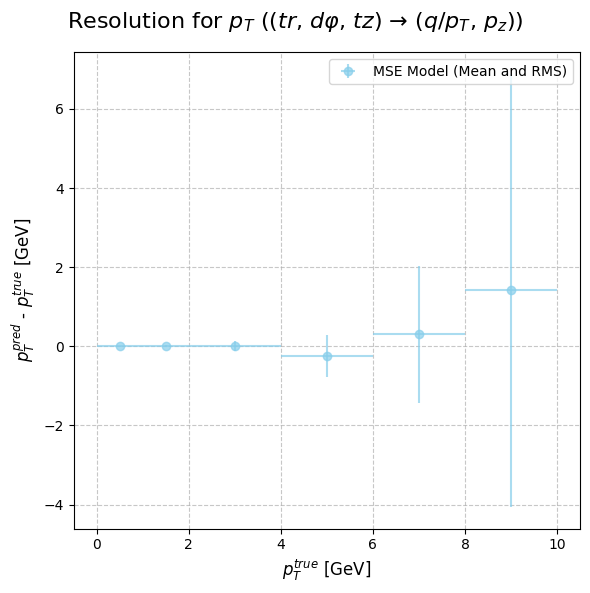

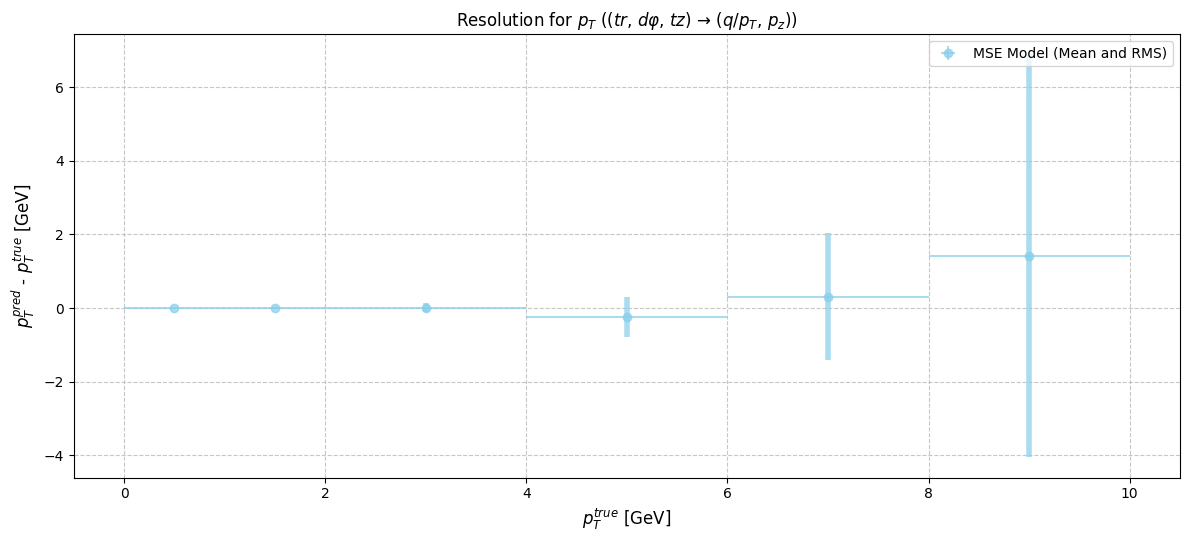

In [39]:
plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    pruning=True,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_resolutions(target_labels=["p_T"], pruning=True)

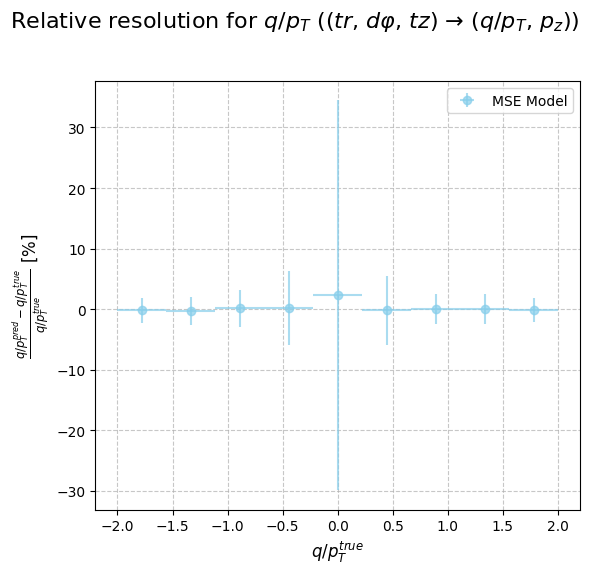

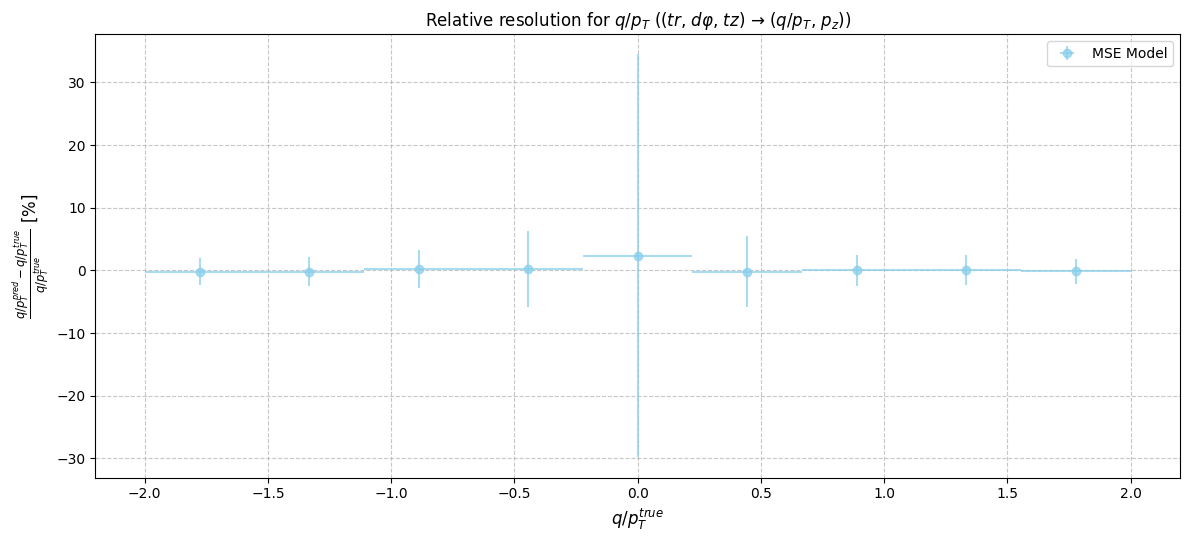

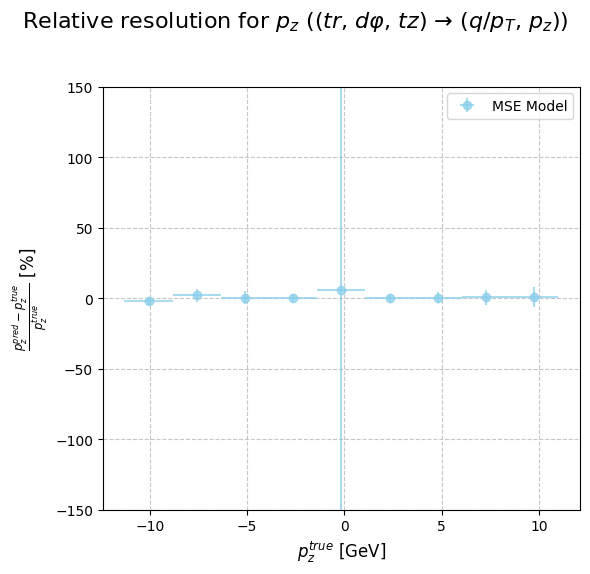

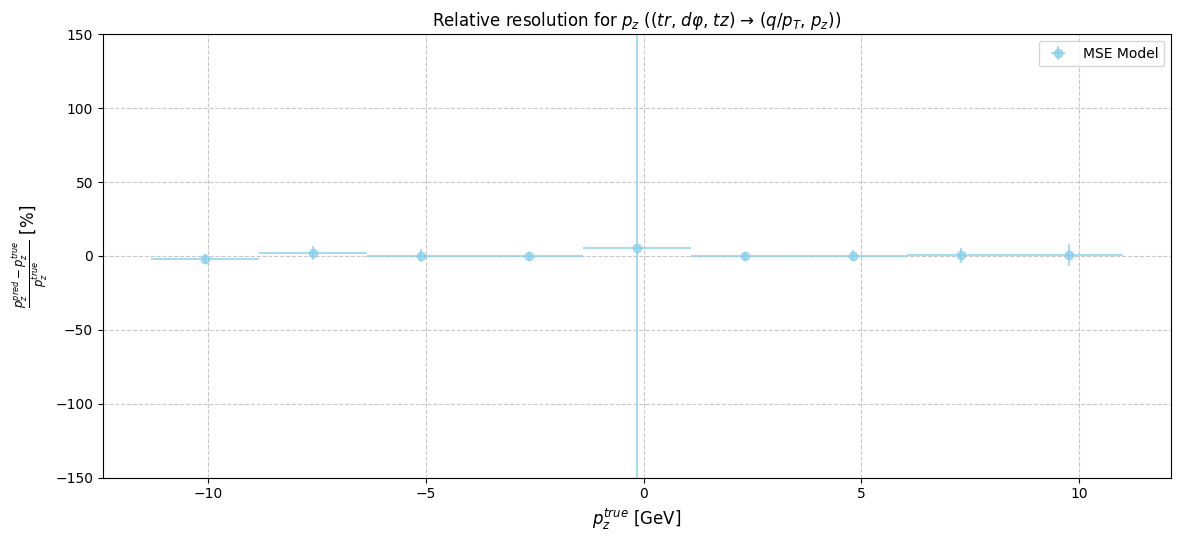

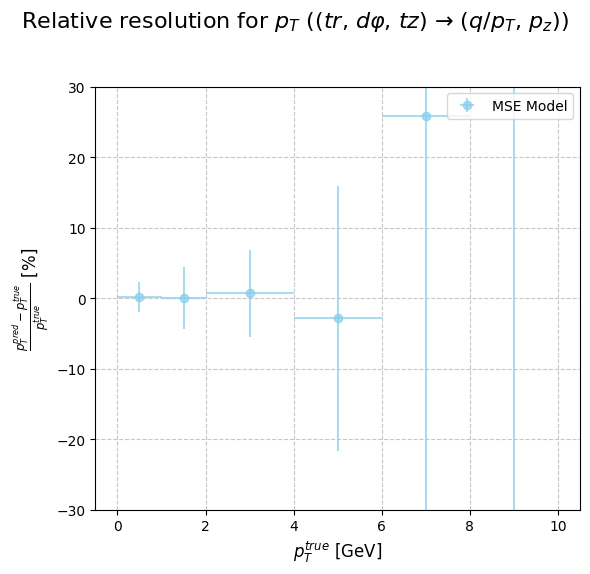

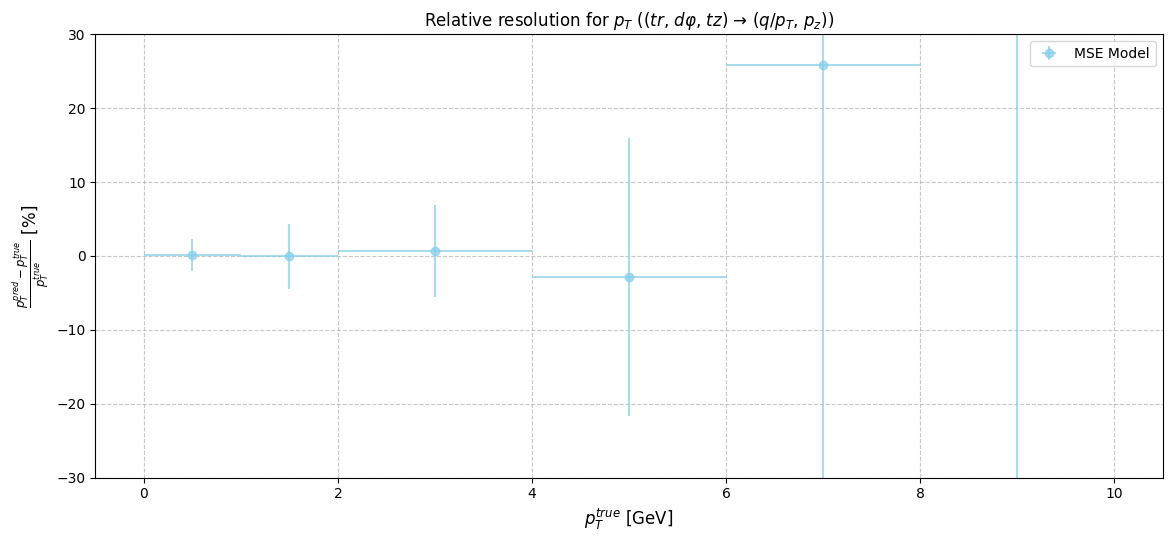

In [40]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=False,
    low_pt=False,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=False,
        low_pt=False,
    )

Fraction of tracks identified as outliers by model MSE: 2.3446% for bin (-1.9999938011169434, -1.5555542310078938)
Fraction of tracks identified as outliers by model MSE: 2.0937% for bin (-1.5555542310078938, -1.1111146608988443)
Fraction of tracks identified as outliers by model MSE: 2.0098% for bin (-1.1111146608988443, -0.6666750907897949)
Fraction of tracks identified as outliers by model MSE: 4.0611% for bin (-0.6666750907897949, -0.22223552068074537)
Fraction of tracks identified as outliers by model MSE: 4.6763% for bin (-0.22223552068074537, 0.22220404942830418)
Fraction of tracks identified as outliers by model MSE: 5.4679% for bin (0.22220404942830418, 0.6666436195373535)
Fraction of tracks identified as outliers by model MSE: 2.4922% for bin (0.6666436195373535, 1.1110831896464033)
Fraction of tracks identified as outliers by model MSE: 2.4848% for bin (1.1110831896464033, 1.5555227597554526)
Fraction of tracks identified as outliers by model MSE: 2.5348% for bin (1.55552275

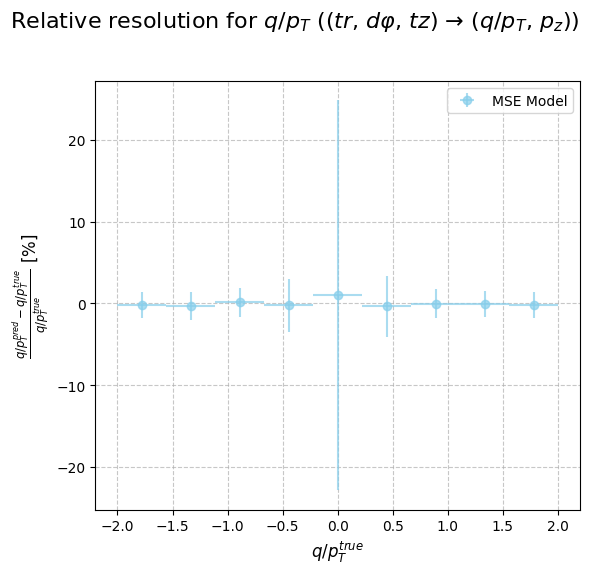

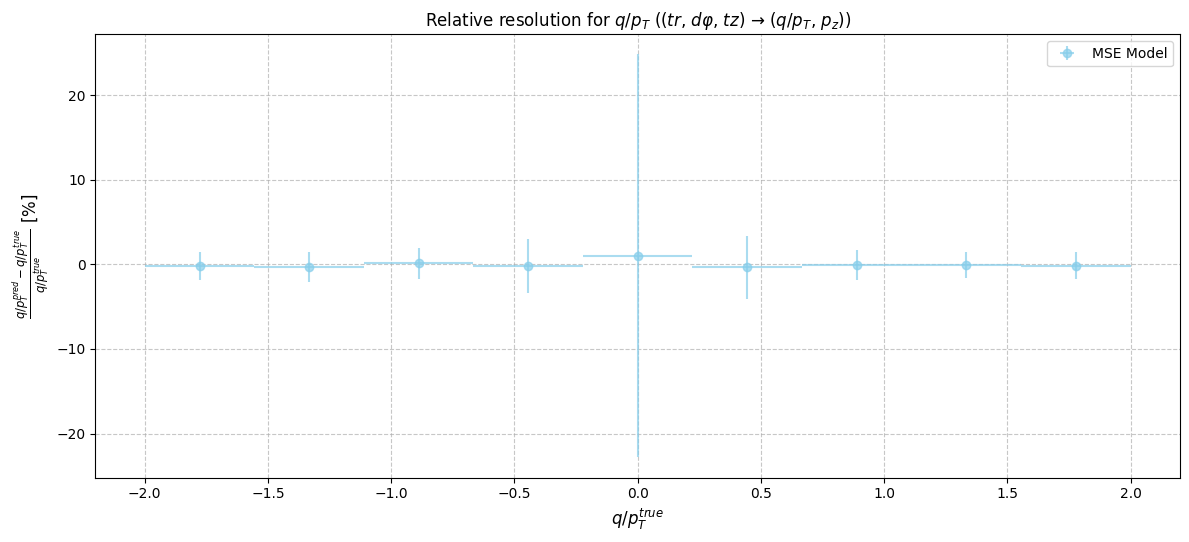

Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-11.307600021362305, -8.828355577256945)
Fraction of tracks identified as outliers by model MSE: 4.7619% for bin (-8.828355577256945, -6.349111133151585)
Fraction of tracks identified as outliers by model MSE: 3.5398% for bin (-6.349111133151585, -3.8698666890462246)
Fraction of tracks identified as outliers by model MSE: 3.0415% for bin (-3.8698666890462246, -1.3906222449408645)
Fraction of tracks identified as outliers by model MSE: 9.5606% for bin (-1.3906222449408645, 1.0886221991644955)
Fraction of tracks identified as outliers by model MSE: 2.7663% for bin (1.0886221991644955, 3.5678666432698556)
Fraction of tracks identified as outliers by model MSE: 2.0270% for bin (3.5678666432698556, 6.047111087375214)
Fraction of tracks identified as outliers by model MSE: 3.4483% for bin (6.047111087375214, 8.526355531480576)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (8.526355531480576, 11

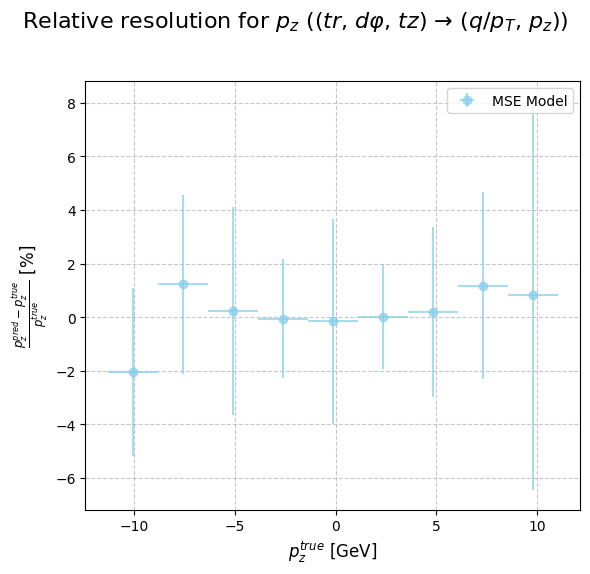

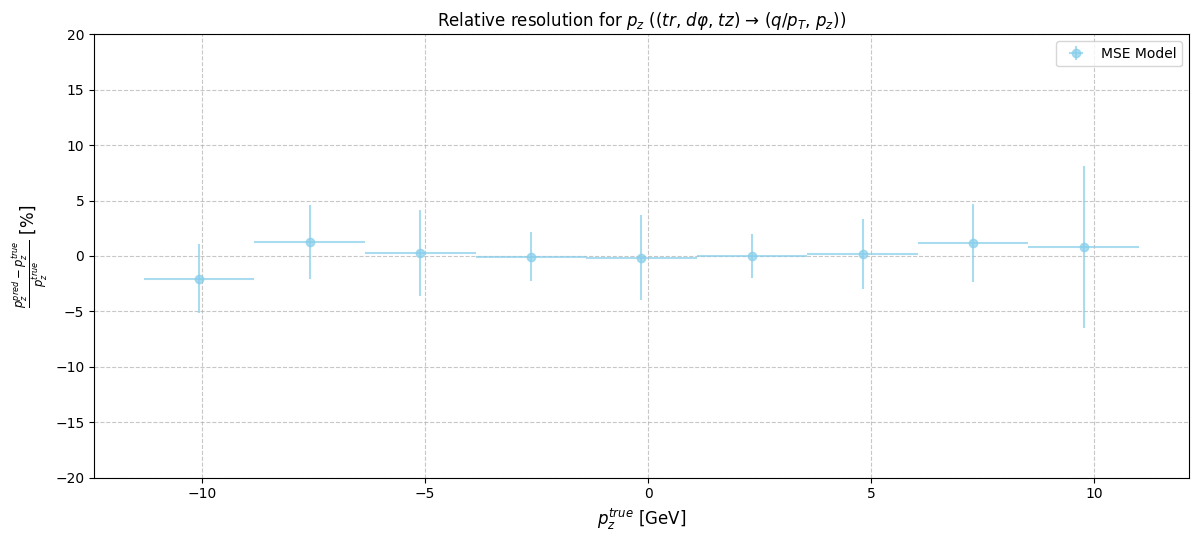

Fraction of tracks identified as outliers by model MSE: 2.3902% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 2.7840% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: 3.9977% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: 5.6995% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: 10.5634% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: 9.0909% for bin (8, 10)


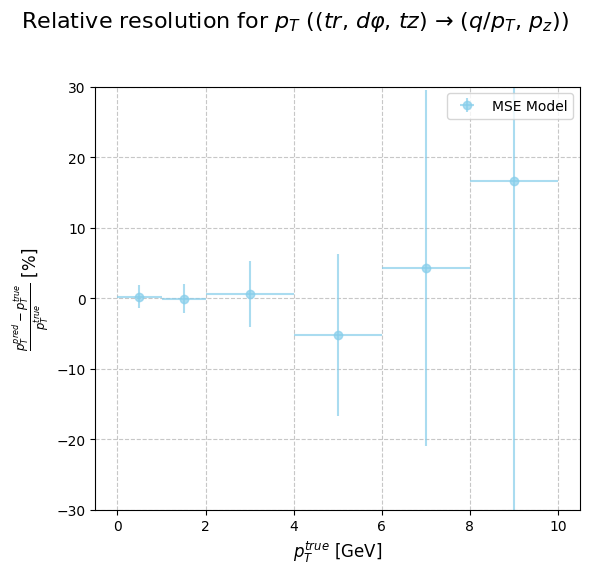

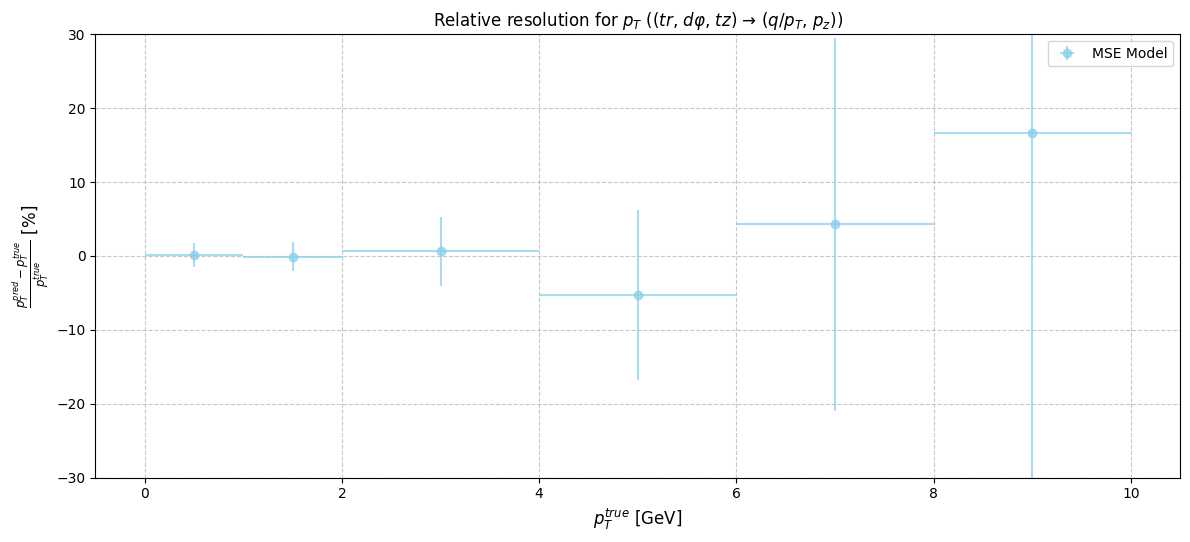

In [41]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=True,
    low_pt=False,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=True,
        low_pt=False,
    )

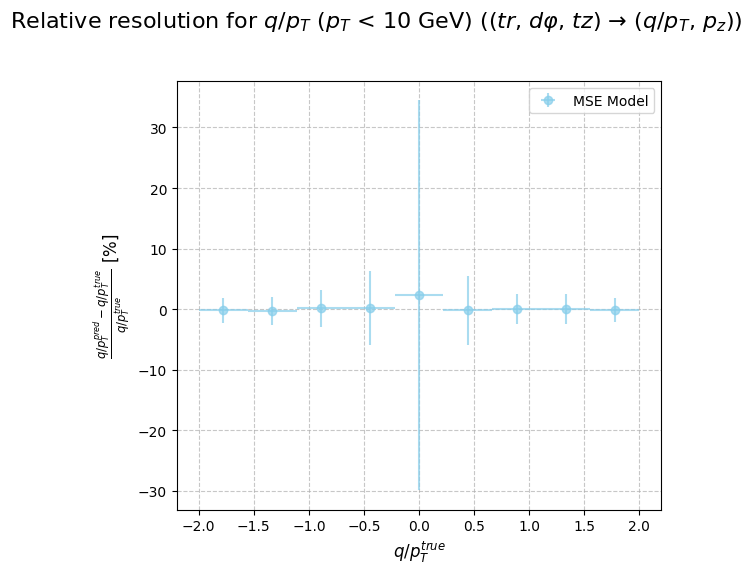

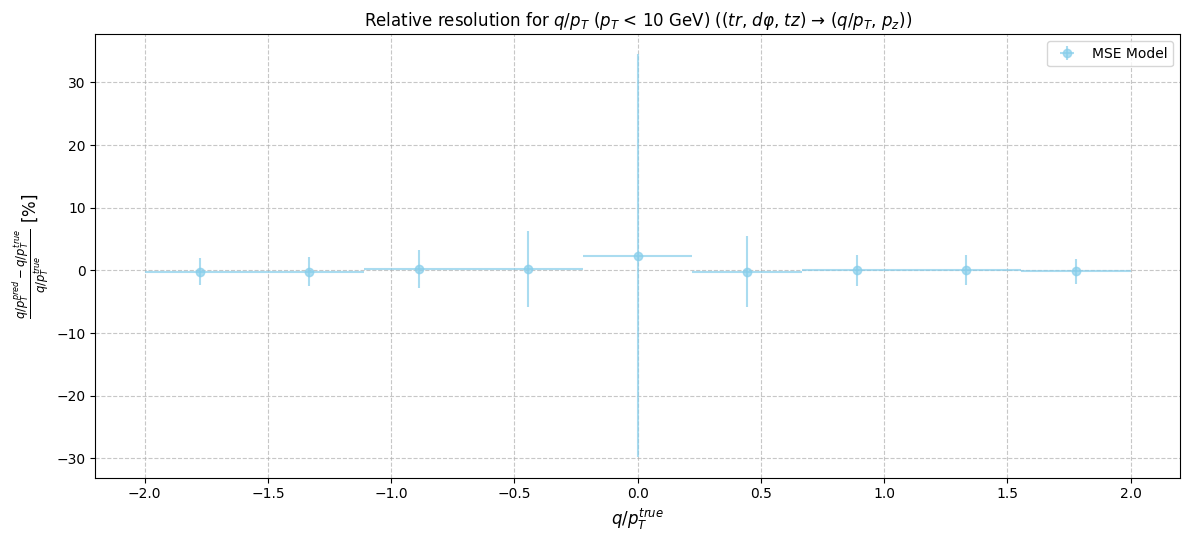

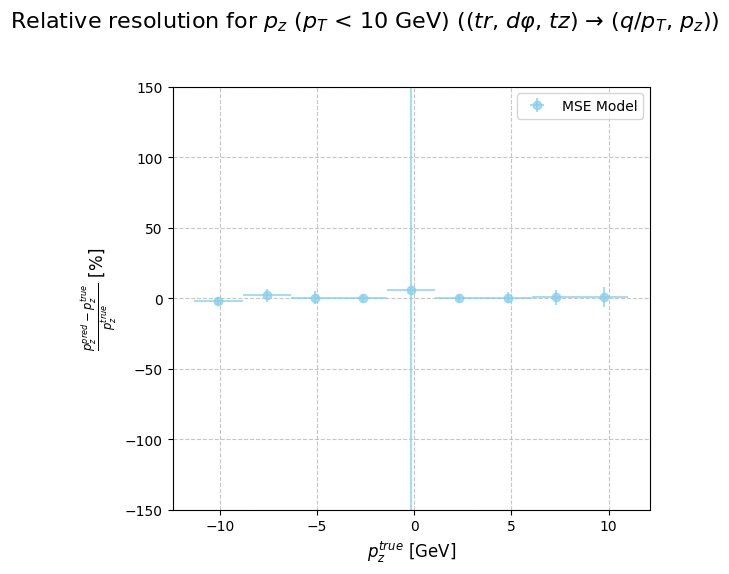

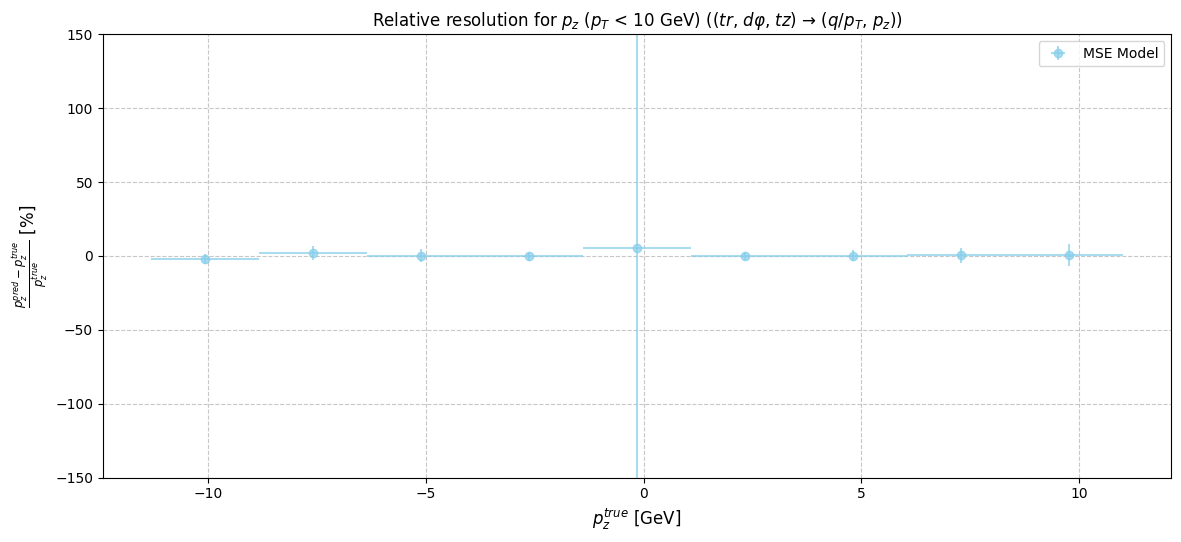

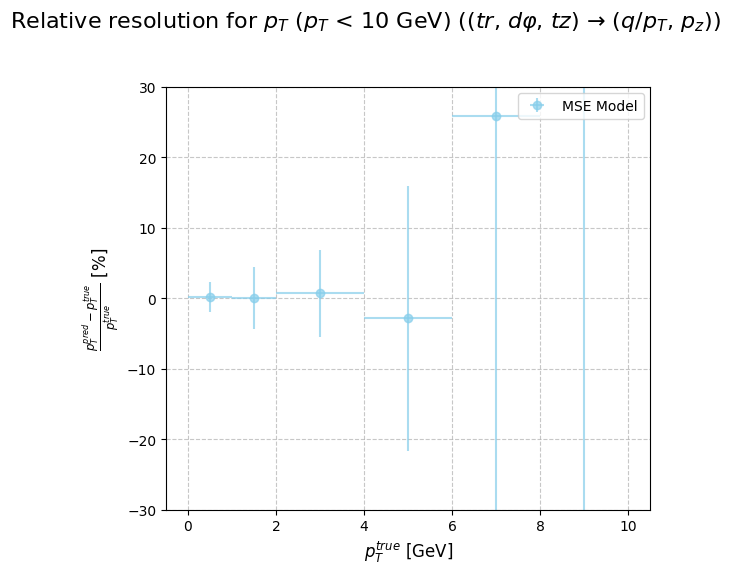

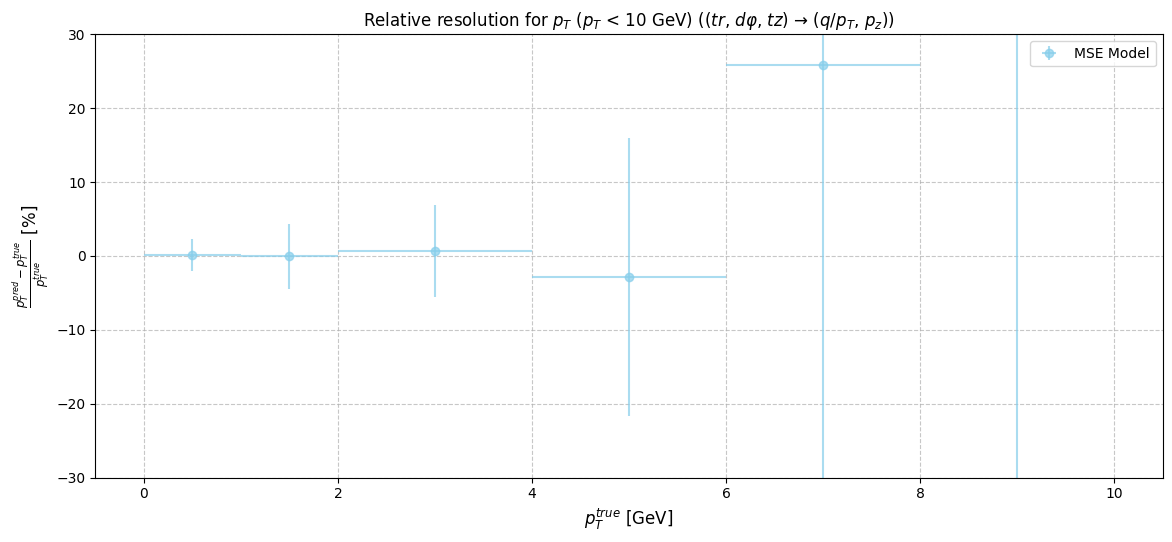

In [42]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=False,
    low_pt=True,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=False,
        low_pt=True,
    )

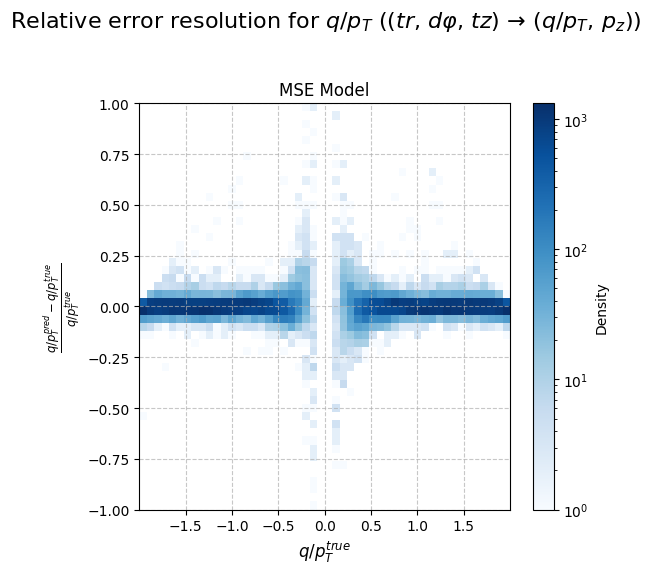

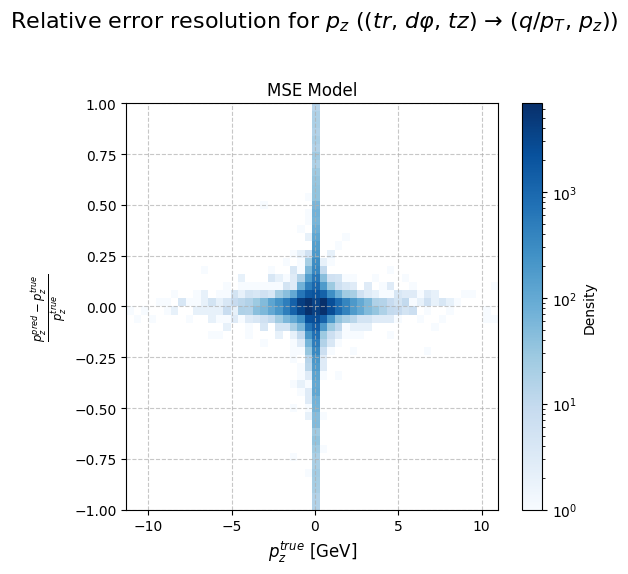

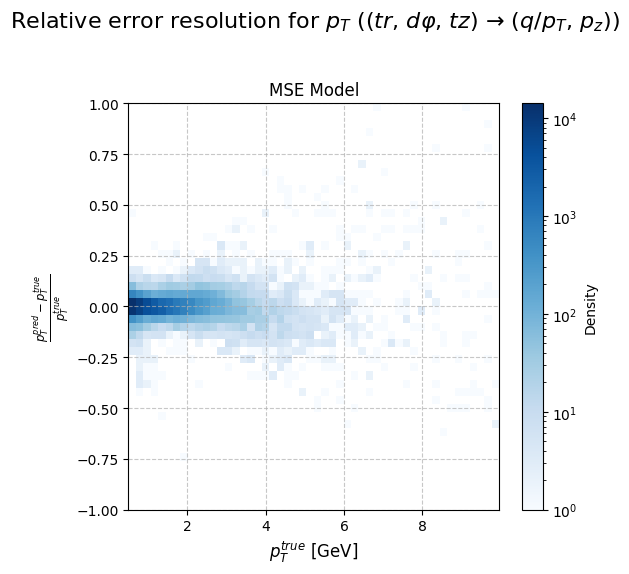

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plot_2d_histogram(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_2d_histogram(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

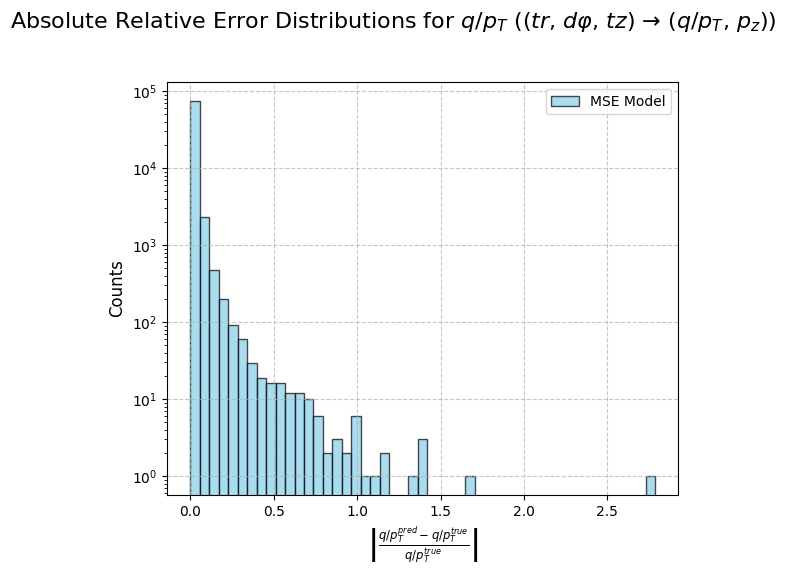

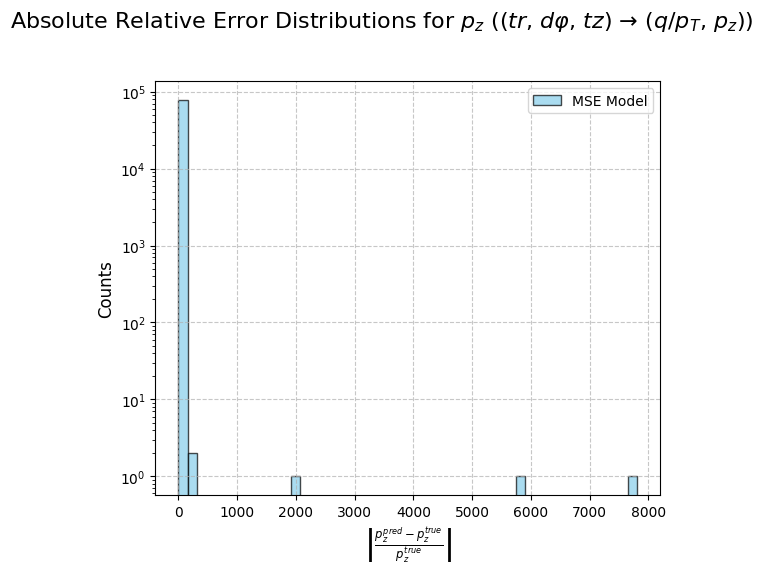

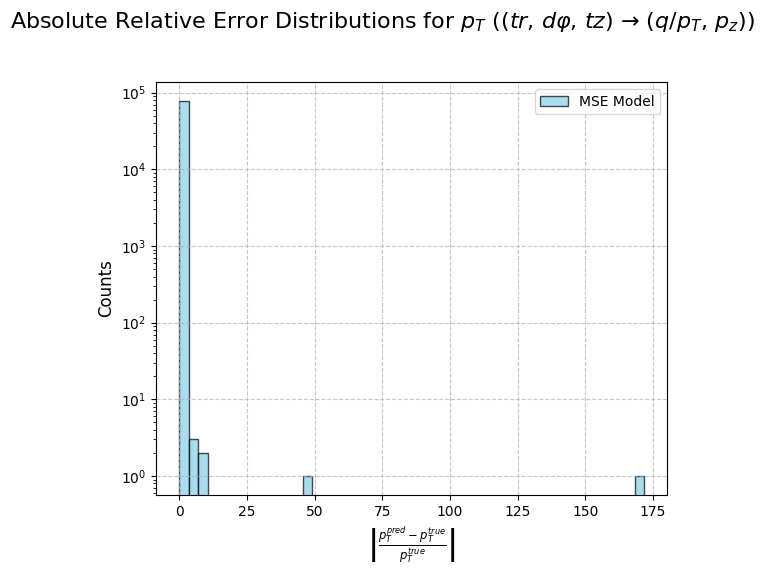

In [44]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=True,
    low_pt=False,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=True,
        low_pt=False,
    )

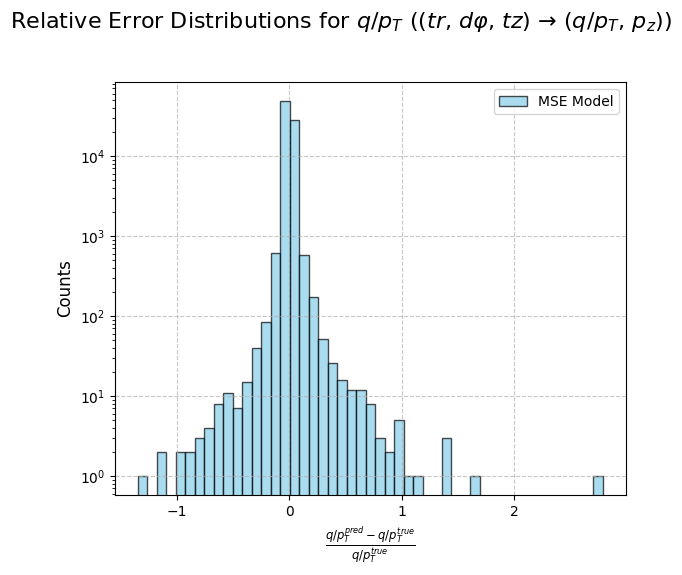

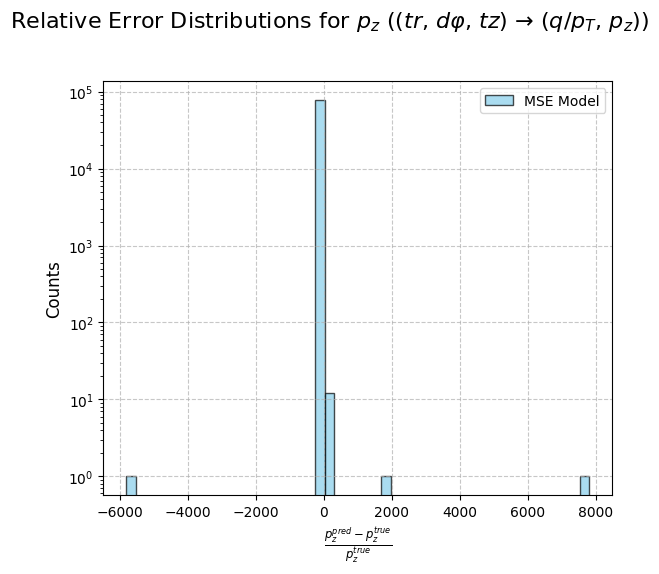

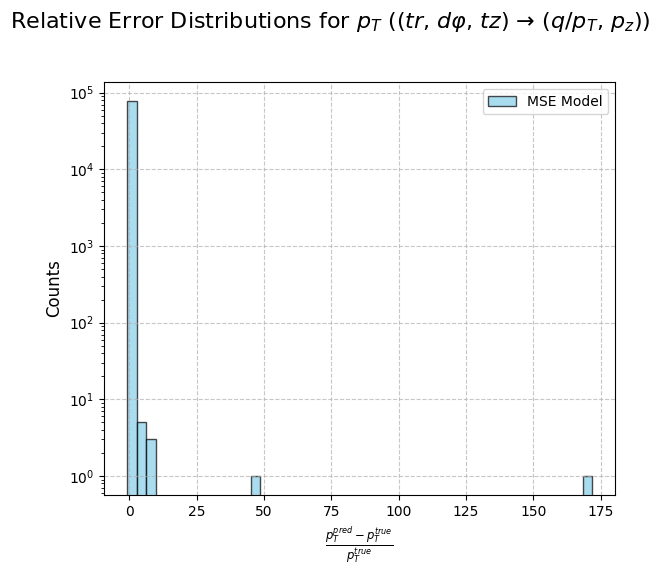

In [45]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=False,
    low_pt=False,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=False,
        low_pt=False,
    )

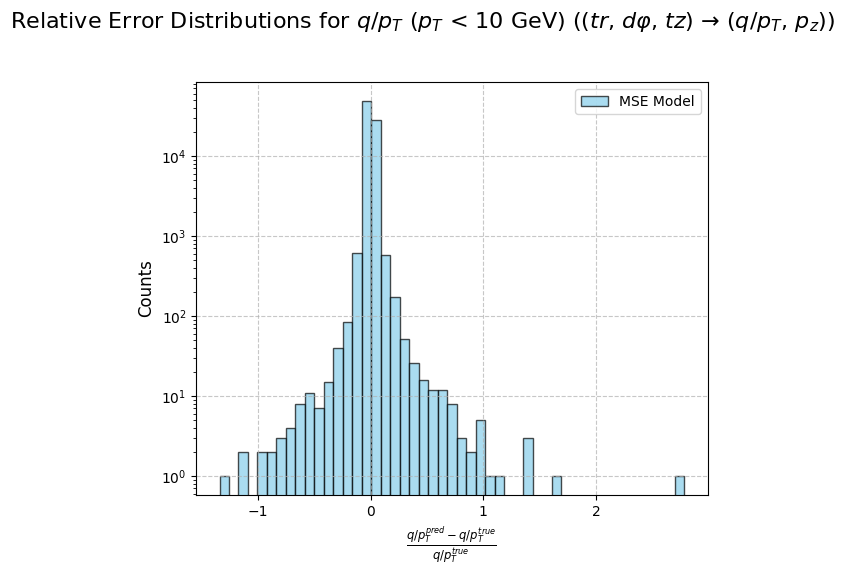

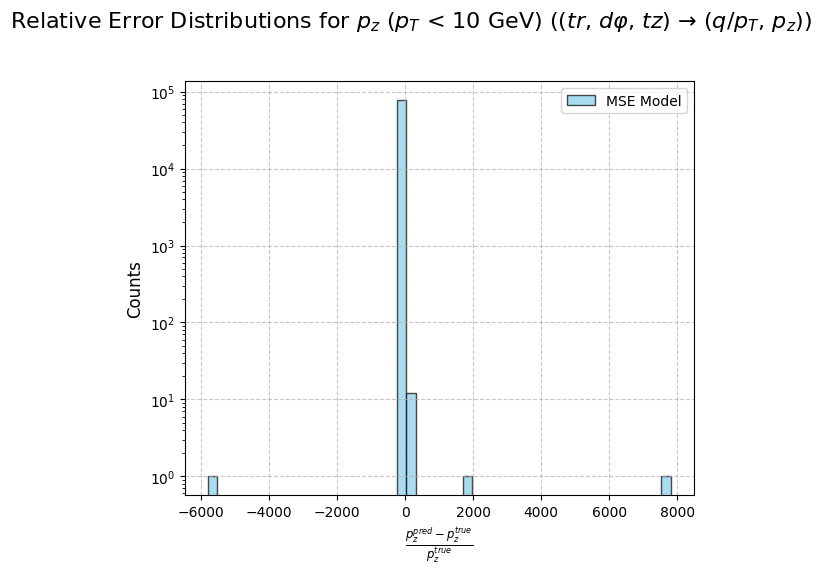

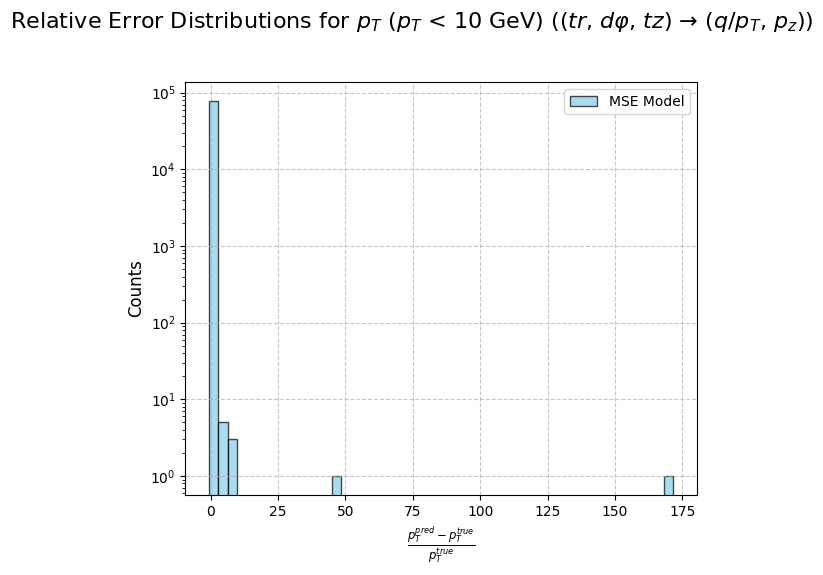

In [46]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=False,
    low_pt=True,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=False,
        low_pt=True,
    )

MSE: -0.0001 +- 0.0417


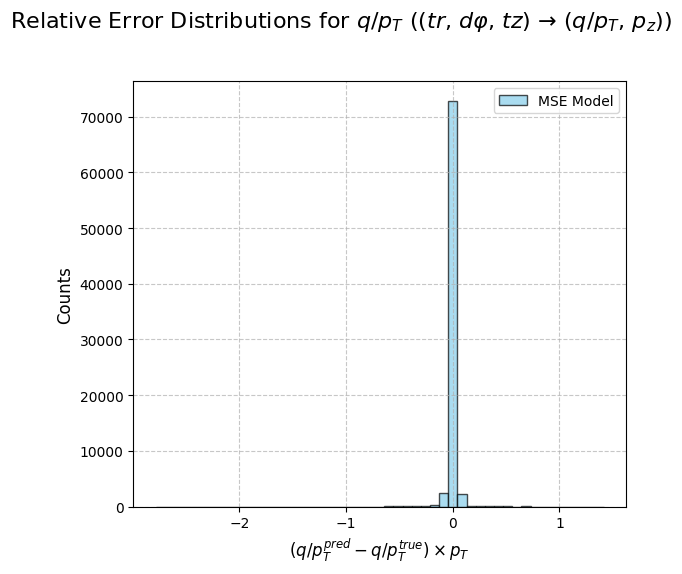

MSE: -0.0000 +- 0.0297


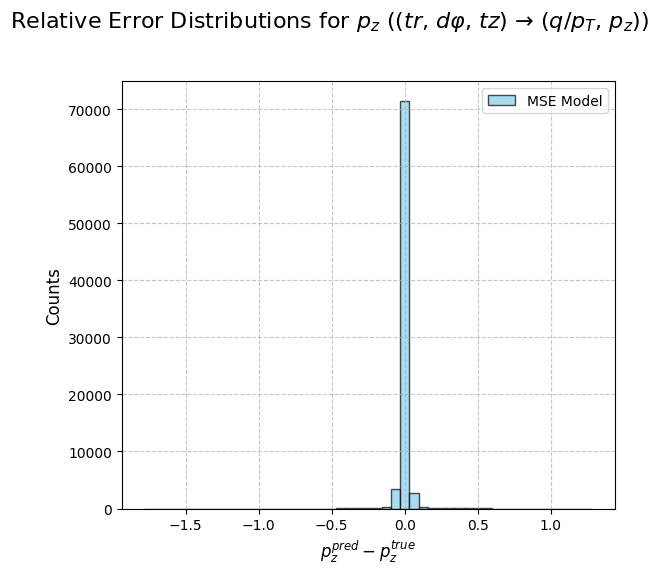

MSE: 0.0334 +- 5.6637


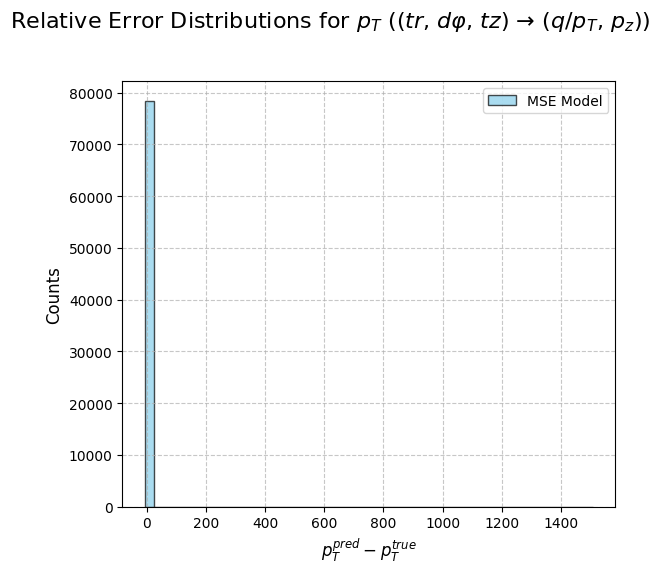

In [47]:
plot_pi_error_distributions_p(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_error_distributions_p(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

In [48]:
def plot_pi_relative_error_distributions_low_pt_1_2__(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )
            pi_pred_mse_list = var_to_pT(
                values=pi_pred_mse_list, from_var=config["output_variables"][var_index]
            )
            pi_pred_qloss_list = var_to_pT(
                values=pi_pred_qloss_list, from_var=config["output_variables"][var_index]
            )

        errors_mse_var = pi_pred_mse_list - pi_true_values
        errors_qloss_var = pi_pred_qloss_list - pi_true_values

        relative_errors_mse_var = errors_mse_var / pi_true_values
        relative_errors_qloss_var = errors_qloss_var / pi_true_values

        pt_true = np.array(p_true_list)[:, 0]
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])
        # Select only events with 1 GeV < p_T < 2 GeV.
        mask = pt_true < 2
        mask = mask & (pt_true > 1)
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]

        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2_fit_comp.png"
        )
        filename = output_dir / filename

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        mean_mse_, std_mse_ = norm.fit(relative_errors_mse_var)
        mean_qloss_, std_qloss_ = norm.fit(relative_errors_qloss_var)

        relative_errors_mse_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_mse_list[mask] / pi_true_values[mask],
        )
        relative_errors_qloss_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_qloss_list[mask] / pi_true_values[mask],
        )

        mean_mse, std_mse = np.mean(relative_errors_mse_var_pruned), np.std(
            relative_errors_mse_var_pruned
        )
        mean_qloss, std_qloss = np.mean(relative_errors_qloss_var_pruned), np.std(
            relative_errors_qloss_var_pruned
        )

        # Do a normal fit
        mean_mse_MLE, std_mse_MLE = norm.fit(relative_errors_mse_var_pruned, method="MLE")
        mean_qloss_MLE, std_qloss_MLE = norm.fit(relative_errors_qloss_var_pruned, method="MLE")

        mean_mse_MM, std_mse_MM = norm.fit(relative_errors_mse_var_pruned, method="MM")
        mean_qloss_MM, std_qloss_MM = norm.fit(relative_errors_qloss_var_pruned, method="MM")

        # Add a real gaussian fit
        from scipy.stats import norm
        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def gaussian(x, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def fit_gaussian(y, x, p0=[0, 0.4]):
            # Remove extra x value
            x = x[:-1]
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 1], bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 0.1], bounds=([0, -3, 0], [np.inf, 3, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-3, 0], [3, 1]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-2, 0], [np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-1.5, 0], [1.5, 35]))
            popt, pcov = curve_fit(
                norm.pdf, x, y, p0=p0, bounds=([-np.inf, 0], [np.inf, np.inf])
            )
            perr = np.sqrt(np.diag(pcov))
            return popt, perr

        # Get the 82% quantile
        from scipy.stats import scoreatpercentile

        quantile_target = (1 - (1 / 1744278)) * 100
        # quantile_target = (1-(1 / 370.398)) * 100
        # quantile_target = (1-(1 / 3.1514872)) * 100
        q_mse = scoreatpercentile(relative_errors_mse_var, quantile_target)
        q_qloss = scoreatpercentile(relative_errors_qloss_var, quantile_target)

        print(f"{quantile_target}% quantile for MSE: {q_mse}")
        print(f"{quantile_target}% quantile for Qloss: {q_qloss}")

        # Same with lower quantile
        low_quantile_target = 100 - quantile_target
        q_low_mse = scoreatpercentile(relative_errors_mse_var, low_quantile_target)
        q_low_qloss = scoreatpercentile(relative_errors_qloss_var, low_quantile_target)

        print(f"{low_quantile_target}% quantile for MSE: {q_low_mse}")
        print(f"{low_quantile_target}% quantile for Qloss: {q_low_qloss}")

        n_sig = 5
        # q_low_qloss = (q_low_qloss-mean_qloss)*n_sig + mean_qloss
        # q_qloss = (q_qloss-mean_qloss)*n_sig + mean_qloss
        # q_low_mse = (q_low_mse-mean_mse)*n_sig + mean_mse
        # q_mse = (q_mse-mean_mse)*n_sig + mean_mse

        q_low_mse = max(q_low_mse, -n_sig * std_mse_ + mean_mse_)
        q_low_qloss = max(q_low_qloss, -n_sig * std_qloss_ + mean_qloss_)
        q_mse = min(q_mse, n_sig * std_mse_ + mean_mse_)
        q_qloss = min(q_qloss, n_sig * std_qloss_ + mean_qloss_)

        if var == "p_z":
            q_low_mse = -2
            q_low_qloss = -2
            q_mse = 2
            q_qloss = 2

        bins = 100
        mse_bins, mse_edges = np.histogram(
            relative_errors_mse_var, bins=bins, density=True, range=(q_low_mse, q_mse)
        )
        qloss_bins, qloss_edges = np.histogram(
            relative_errors_qloss_var,
            bins=bins,
            density=True,
            range=(q_low_qloss, q_qloss),
        )

        mse_fit, mse_fit_err = fit_gaussian(
            mse_bins, mse_edges, p0=[mean_mse_, std_mse_]
        )
        qloss_fit, qloss_fit_err = fit_gaussian(
            qloss_bins, qloss_edges, p0=[mean_qloss_, std_qloss_]
        )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_mse_var_pruned,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model (Pruned)",
            color="blue",
            edgecolor="black",
            density=True,
        )

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_mse, std_mse)
        p_MLE = norm.pdf(x, mean_mse_MLE, std_mse_MLE)
        p_MM = norm.pdf(x, mean_mse_MM, std_mse_MM)
        p_fit = norm.pdf(x, *mse_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (MSE) \nMean: {mean_mse:5.3f}, Std: {std_mse:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (MSE) \nMean: {mean_mse_MLE:5.3f}, Std: {std_mse_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (MSE) \nMean: {mean_mse_MM:5.3f}, Std: {std_mse_MM:5.3f}",
        )

        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (MSE) \nMean: {mse_fit[0]:5.3f} +/- {mse_fit_err[0]:5.3f}\nStd: {mse_fit[1]:5.3f} +/- {mse_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # Limit at 5 sigma
        plt.xlim(q_low_mse, q_mse)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_qloss_var_pruned,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model (Pruned)",
            color="red",
            edgecolor="black",
            density=True,
        )

        # Limit at 5 sigma
        plt.xlim(q_low_qloss, q_qloss)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_qloss, std_qloss)
        p_MLE = norm.pdf(x, mean_qloss_MLE, std_qloss_MLE)
        p_MM = norm.pdf(x, mean_qloss_MM, std_qloss_MM)
        p_fit = norm.pdf(x, *qloss_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (Qloss) \nMean: {mean_qloss:5.3f}, Std: {std_qloss:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (Qloss) \nMean: {mean_qloss_MLE:5.3f}, Std: {std_qloss_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (Qloss) \nMean: {mean_qloss_MM:5.3f}, Std: {std_qloss_MM:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (Qloss) \nMean: {qloss_fit[0]:5.3f} +/- {qloss_fit_err[0]:5.3f}\nStd: {qloss_fit[1]:5.3f} +/- {qloss_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse, std_mse), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse_, std_mse_), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, *mse_fit), neglog=True)}"
        )


# plot_pi_relative_error_distributions_low_pt_1_2__(
#     target_labels=[variable_labels[var] for var in config["output_variables"]]
# )
# if config["output_variables"][0] in ["qopT", "qpT"]:
#     plot_pi_relative_error_distributions_low_pt_1_2__(target_labels=["p_T"])

In [49]:
def plot_pi_relative_error_distributions_low_pt_1_2___(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )
            pi_pred_mse_list = var_to_pT(
                values=pi_pred_mse_list, from_var=config["output_variables"][var_index]
            )
            pi_pred_qloss_list = var_to_pT(
                values=pi_pred_qloss_list, from_var=config["output_variables"][var_index]
            )

        errors_mse_var = pi_pred_mse_list - pi_true_values
        errors_qloss_var = pi_pred_qloss_list - pi_true_values

        relative_errors_mse_var = errors_mse_var / pi_true_values
        relative_errors_qloss_var = errors_qloss_var / pi_true_values

        pt_true = np.array(p_true_list)[:, 0]
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])
        # Select only events with 1 GeV < p_T < 2 GeV.
        mask = pt_true < 2
        mask = mask & (pt_true > 1)
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]

        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2_fit_comp.png"
        )
        filename = output_dir / filename

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        mean_mse_, std_mse_ = norm.fit(relative_errors_mse_var)
        mean_qloss_, std_qloss_ = norm.fit(relative_errors_qloss_var)

        relative_errors_mse_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_mse_list[mask] / pi_true_values[mask],
        )
        relative_errors_qloss_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_qloss_list[mask] / pi_true_values[mask],
        )

        mean_mse, std_mse = np.mean(relative_errors_mse_var_pruned), np.std(
            relative_errors_mse_var_pruned
        )
        mean_qloss, std_qloss = np.mean(relative_errors_qloss_var_pruned), np.std(
            relative_errors_qloss_var_pruned
        )

        # Do a normal fit
        mean_mse_MLE, std_mse_MLE = norm.fit(relative_errors_mse_var_pruned, method="MLE")
        mean_qloss_MLE, std_qloss_MLE = norm.fit(relative_errors_qloss_var_pruned, method="MLE")

        mean_mse_MM, std_mse_MM = norm.fit(relative_errors_mse_var_pruned, method="MM")
        mean_qloss_MM, std_qloss_MM = norm.fit(relative_errors_qloss_var_pruned, method="MM")

        lower_bound_mse, upper_bound_mse, interval_center_mse = get_smallest_confidence_interval(relative_errors_mse_var)
        print(f"{lower_bound_mse = }, {upper_bound_mse = } {interval_center_mse = }")
        lower_bound_sigma_mse = lower_bound_mse - interval_center_mse
        upper_bound_sigma_mse = upper_bound_mse - interval_center_mse
        print(f"{lower_bound_sigma_mse = }, {upper_bound_sigma_mse = } {interval_center_mse = }")

        lower_bound_qloss, upper_bound_qloss, interval_center_qloss = get_smallest_confidence_interval(relative_errors_qloss_var)
        print(f"{lower_bound_qloss = }, {upper_bound_qloss = } {interval_center_qloss = }")
        lower_bound_sigma_qloss = lower_bound_qloss - interval_center_qloss
        upper_bound_sigma_qloss = upper_bound_qloss - interval_center_qloss
        print(f"{lower_bound_sigma_qloss = }, {upper_bound_sigma_qloss = } {interval_center_qloss = }")
        

        

        # Add a real gaussian fit
        from scipy.stats import norm
        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def gaussian(x, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def fit_gaussian(y, x, p0=[0, 0.4]):
            # Remove extra x value
            x = x[:-1]
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 1], bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 0.1], bounds=([0, -3, 0], [np.inf, 3, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-3, 0], [3, 1]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-2, 0], [np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-1.5, 0], [1.5, 35]))
            popt, pcov = curve_fit(
                norm.pdf, x, y, p0=p0, bounds=([-np.inf, 0], [np.inf, np.inf])
            )
            perr = np.sqrt(np.diag(pcov))
            return popt, perr

        # Get the 82% quantile
        from scipy.stats import scoreatpercentile

        quantile_target = (1 - (1 / 1744278)) * 100
        # quantile_target = (1-(1 / 370.398)) * 100
        # quantile_target = (1-(1 / 3.1514872)) * 100
        q_mse = scoreatpercentile(relative_errors_mse_var, quantile_target)
        q_qloss = scoreatpercentile(relative_errors_qloss_var, quantile_target)

        print(f"{quantile_target}% quantile for MSE: {q_mse}")
        print(f"{quantile_target}% quantile for Qloss: {q_qloss}")

        # Same with lower quantile
        low_quantile_target = 100 - quantile_target
        q_low_mse = scoreatpercentile(relative_errors_mse_var, low_quantile_target)
        q_low_qloss = scoreatpercentile(relative_errors_qloss_var, low_quantile_target)

        print(f"{low_quantile_target}% quantile for MSE: {q_low_mse}")
        print(f"{low_quantile_target}% quantile for Qloss: {q_low_qloss}")

        n_sig = 5
        # q_low_qloss = (q_low_qloss-mean_qloss)*n_sig + mean_qloss
        # q_qloss = (q_qloss-mean_qloss)*n_sig + mean_qloss
        # q_low_mse = (q_low_mse-mean_mse)*n_sig + mean_mse
        # q_mse = (q_mse-mean_mse)*n_sig + mean_mse

        q_low_mse = max(q_low_mse, -n_sig * std_mse_ + mean_mse_)
        q_low_qloss = max(q_low_qloss, -n_sig * std_qloss_ + mean_qloss_)
        q_mse = min(q_mse, n_sig * std_mse_ + mean_mse_)
        q_qloss = min(q_qloss, n_sig * std_qloss_ + mean_qloss_)

        if var == "p_z":
            q_low_mse = -2
            q_low_qloss = -2
            q_mse = 2
            q_qloss = 2

        bins = 100
        mse_bins, mse_edges = np.histogram(
            relative_errors_mse_var, bins=bins, density=True, range=(q_low_mse, q_mse)
        )
        qloss_bins, qloss_edges = np.histogram(
            relative_errors_qloss_var,
            bins=bins,
            density=True,
            range=(q_low_qloss, q_qloss),
        )

        mse_fit, mse_fit_err = fit_gaussian(
            mse_bins, mse_edges, p0=[mean_mse_, std_mse_]
        )
        qloss_fit, qloss_fit_err = fit_gaussian(
            qloss_bins, qloss_edges, p0=[mean_qloss_, std_qloss_]
        )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_mse_var_pruned,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model (Pruned)",
            color="blue",
            edgecolor="black",
            density=True,
        )

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_mse, std_mse)
        p_MLE = norm.pdf(x, mean_mse_MLE, std_mse_MLE)
        p_MM = norm.pdf(x, mean_mse_MM, std_mse_MM)
        p_fit = norm.pdf(x, *mse_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (MSE) \nMean: {mean_mse:5.3f}, Std: {std_mse:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (MSE) \nMean: {mean_mse_MLE:5.3f}, Std: {std_mse_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (MSE) \nMean: {mean_mse_MM:5.3f}, Std: {std_mse_MM:5.3f}",
        )

        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (MSE) \nMean: {mse_fit[0]:5.3f} +/- {mse_fit_err[0]:5.3f}\nStd: {mse_fit[1]:5.3f} +/- {mse_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # Limit at 5 sigma
        plt.xlim(q_low_mse, q_mse)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_qloss_var_pruned,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model (Pruned)",
            color="red",
            edgecolor="black",
            density=True,
        )

        # Limit at 5 sigma
        plt.xlim(q_low_qloss, q_qloss)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_qloss, std_qloss)
        p_MLE = norm.pdf(x, mean_qloss_MLE, std_qloss_MLE)
        p_MM = norm.pdf(x, mean_qloss_MM, std_qloss_MM)
        p_fit = norm.pdf(x, *qloss_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (Qloss) \nMean: {mean_qloss:5.3f}, Std: {std_qloss:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (Qloss) \nMean: {mean_qloss_MLE:5.3f}, Std: {std_qloss_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (Qloss) \nMean: {mean_qloss_MM:5.3f}, Std: {std_qloss_MM:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (Qloss) \nMean: {qloss_fit[0]:5.3f} +/- {qloss_fit_err[0]:5.3f}\nStd: {qloss_fit[1]:5.3f} +/- {qloss_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        # plt.savefig(filename, format="png")
        plt.show()
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse, std_mse), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse_, std_mse_), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, *mse_fit), neglog=True)}"
        )


# plot_pi_relative_error_distributions_low_pt_1_2___(
#     target_labels=[variable_labels[var] for var in config["output_variables"]]
# )
# if config["output_variables"][0] in ["qopT", "qpT"]:
#     plot_pi_relative_error_distributions_low_pt_1_2___(target_labels=["p_T"])

In [50]:
import ROOT
%jsroot on

In [51]:
import ROOT
import numpy as np


def plot_pi_relative_error_distributions_low_pt_1_2_(target_labels):
    # Set ROOT to batch mode so no GUI windows are opened.
    ROOT.gROOT.SetBatch(True)

    # Try to load and set ATLAS style (make sure AtlasStyle.C is in your working directory or adjust the path).
    try:
        ROOT.gROOT.LoadMacro("AtlasStyle.C")
        ROOT.SetAtlasStyle()
    except Exception as e:
        print("AtlasStyle.C not found. Proceeding with default ROOT style.")
        ROOT.gROOT.SetStyle("12ATLAS")

    # Loop over each variable (assumed that target_labels is a list of variable names).
    for var_index, var in enumerate(target_labels):
        # Get the true values for the current variable.
        pi_true_values = np.array(p_true_list)[:, var_index]
        if var == "p_T":
            # Convert the true values to pT if the variable is pT.
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )

        # Get the transverse momentum values (assumed to be the first column).
        pt_true = np.array(p_true_list)[:, 0]
        # Convert the transverse momentum values to the current variable.
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])

        # Apply the pT mask: only select events with 1 < p_T < 2 GeV.
        mask = (pt_true > 1) & (pt_true < 2)

        # Loop over each model.
        for model_name, model_info in models.items():
            # Create a separate canvas for this variable and model.
            canvas = ROOT.TCanvas(
                f"canvas_{model_name}_{var}",
                f"Relative Error Distribution for {var} with {model_name} (1 < p_T < 2 GeV)",
                800,
                600,
            )

            # Compute the relative error: (prediction - true)/true.
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if var == "p_T":
                pi_pred_values = var_to_pT(
                    values=pi_pred_values, from_var=config["output_variables"][var_index]
                )
            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            # Apply the same pT mask.
            relative_errors = relative_errors[mask]

            # Create the histogram.
            bins = 50
            hist = ROOT.TH1F(
                f"hist_{model_name}_{var}",
                f"{model_name} Model: Relative Error Distribution for {var} (1 < p_T < 2 GeV)",
                bins,
                np.min(relative_errors),
                np.max(relative_errors),
            )
            # Fill the histogram.
            for err in relative_errors:
                hist.Fill(err)
            # Normalize the histogram if there are entries.
            if hist.Integral() > 0:
                hist.Scale(1.0 / hist.Integral())

            # Set histogram style.
            hist.SetLineColor(model_info["color"])
            hist.SetFillColorAlpha(model_info["color"], 0.3)
            hist.Draw("HIST")

            # Fit a Gaussian to the histogram.
            fit = ROOT.TF1(
                f"fit_{model_name}_{var}",
                "gaus",
                np.min(relative_errors),
                np.max(relative_errors),
            )
            hist.Fit(fit, "R")
            fit.SetLineColor(ROOT.kBlack)
            fit.Draw("SAME")

            # Retrieve the fit parameters.
            mean_fit = fit.GetParameter(1)
            sigma_fit = fit.GetParameter(2)

            # Create a legend to display the fit parameters.
            legend = ROOT.TLegend(0.60, 0.70, 0.90, 0.85)
            legend.SetBorderSize(0)
            legend.SetFillStyle(0)
            # Add the fit function as an entry with a label showing the fit parameters.
            legend.AddEntry(
                fit, f"Fit: Mean = {mean_fit:.3f}, #sigma = {sigma_fit:.3f}", "l"
            )
            legend.Draw("SAME")

            # Update the canvas and save the image.
            canvas.Modified()
            canvas.Update()
            filename = f"relative_error_distribution_{model_name}_{variable_filenames[var]}_low_pt_1_2.png"
            canvas.SaveAs(filename)


# Call the function to generate and save the plots.
# plot_pi_relative_error_distributions_low_pt_1_2_(target_labels=[variable_labels[var] for var in config['output_variables']])

99.9999% quantile for MSE: 2.7506537976578405
0.00010000000000331966% quantile for MSE: -1.1457600325370347
Pruned fit for MSE: (0.0008420970853706355, 0.024491974487672867)
MSE fit: mean_fit = 0.0009265616679846353 +/- mean_fit_err = 0.00014243784467257885 sigma_fit = 0.02043172072998631 +/- sigma_fit_err = 0.00012578586531613797


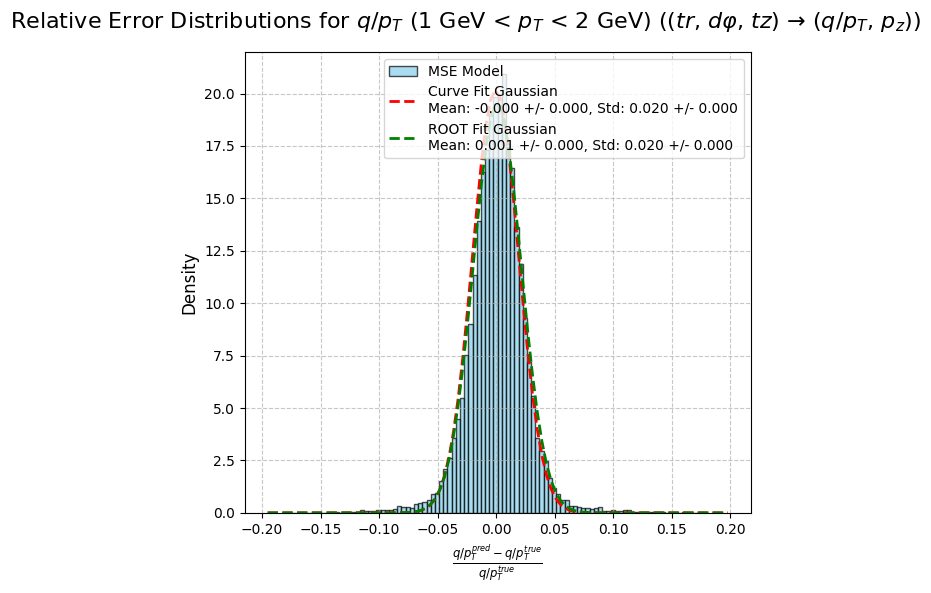

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

invalid value encountered in reduce



Likelihood Curve Fit MSE: nan
Likelihood ROOT Fit MSE: nan
99.9999% quantile for MSE: 128.5830445957142
0.00010000000000331966% quantile for MSE: -5675.113708802415
Pruned fit for MSE: (-0.0034974285006743222, 0.11359176223590672)
MSE fit: mean_fit = -3.793682849676282e-05 +/- mean_fit_err = 0.00022665459785212736 sigma_fit = 0.0314589435046722 +/- sigma_fit_err = 0.00020126977251992695


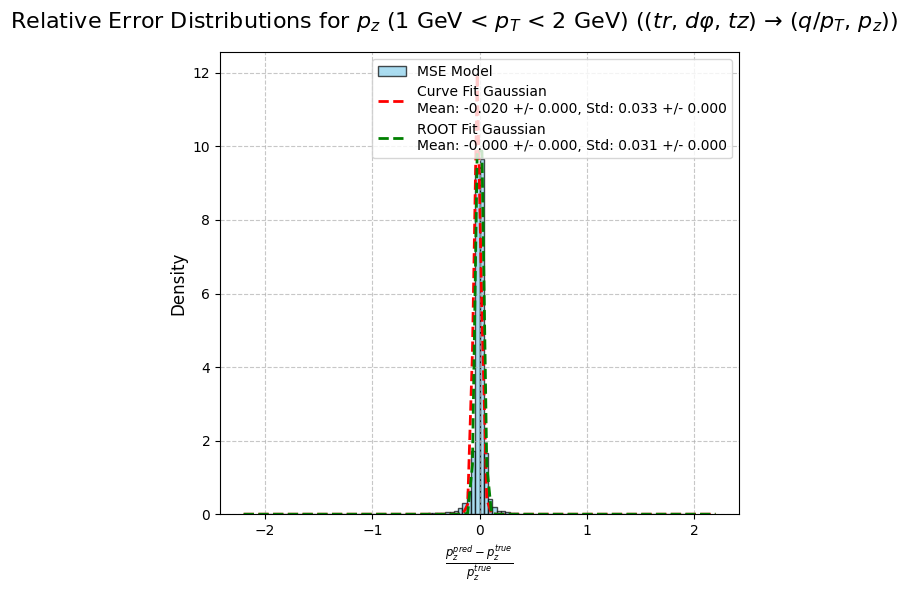

Likelihood Curve Fit MSE: 0.0
Likelihood ROOT Fit MSE: 0.0
99.9999% quantile for MSE: 4.937899716141953
0.00010000000000331966% quantile for MSE: -0.7315630411334798
Pruned fit for MSE: (-0.0002971102712113633, 0.024798173479087103)
MSE fit: mean_fit = -0.0008231439646317776 +/- mean_fit_err = 0.00014318396391338259 sigma_fit = 0.020353972613002144 +/- sigma_fit_err = 0.00012563502769820725


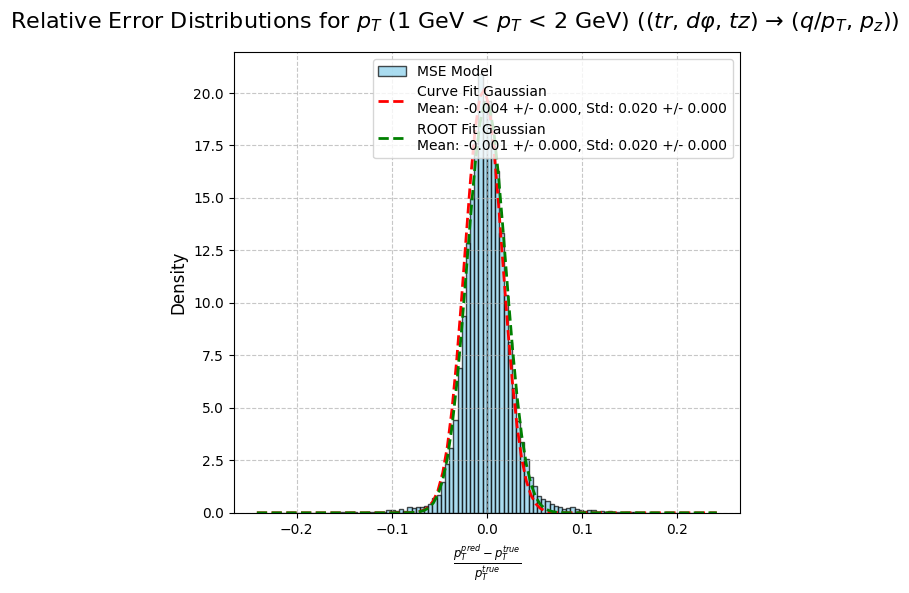

Likelihood Curve Fit MSE: nan
Likelihood ROOT Fit MSE: nan
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      604.495
NDf                       =           89
Edm                       =  2.97616e-07
NCalls                    =           63
Constant                  =    0.0677858   +/-   0.000629428 
Mean                      =  0.000926562   +/-   0.000142438 
Sigma                     =    0.0204317   +/-   0.000125786  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1974.14
NDf                       =           82
Edm                       =  7.44258e-09
NCalls                    =          143
Constant                  =     0.460132   +/-   0.00443232  
Mean                      = -3.79368e-05   +/-   0.000226655 
Sigma                     =    0.0314589   +/-   0.00020127   	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2

Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


In [52]:
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions_low_pt_1_2(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
    )

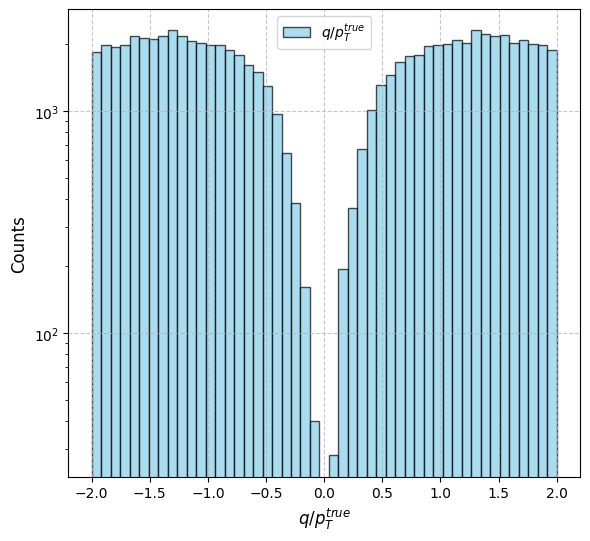

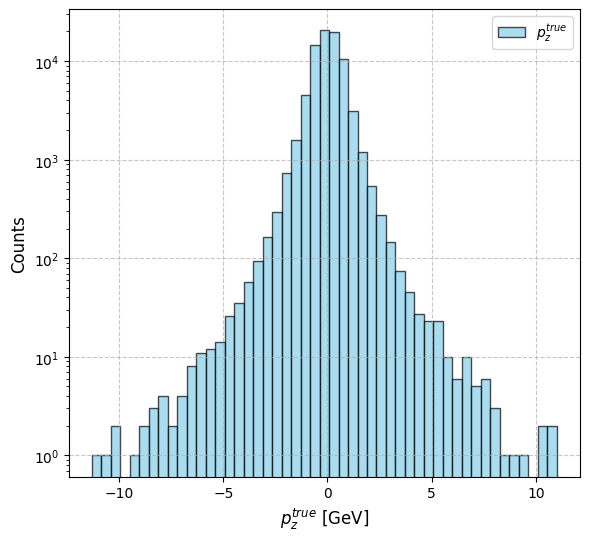

In [53]:
def plot_alone_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        title = f"${var}^{{true}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        filename = f"{variable_filenames[var]}_true.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6, 6))

        bins = np.linspace(
            min(pi_true_values),
            max(pi_true_values),
            50,
        )

        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        # plt.title(title)
        plt.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_alone_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

In [54]:
def plot_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"${var}$" + (" [GeV]" if var.startswith("p") else "")
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred.png"
        )
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi(target_labels=[variable_labels[var] for var in config["output_variables"]])

NameError: name 'p_pred_mse_list' is not defined

In [ ]:
def plot_pi_cdf(target_labels):
    """Plot CDF of p_T and p_z"""
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"CDF of ${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"CDF of ${var}$"
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred_cdf.png"
        )
        filename = output_dir / filename

        # Import necessary CDF function
        from scipy.stats import norm

        pi_true_values_cdf = np.sort(pi_true_values)
        pi_pred_mse_list_cdf = np.sort(pi_pred_mse_list)
        pi_pred_qloss_list_cdf = np.sort(pi_pred_qloss_list)

        pi_true_values_cdf_ = np.linspace(0, 1, len(pi_true_values_cdf))
        pi_pred_mse_list_cdf_ = np.linspace(0, 1, len(pi_pred_mse_list_cdf))
        pi_pred_qloss_list_cdf_ = np.linspace(0, 1, len(pi_pred_qloss_list_cdf))

        pi_true_values_cdf = norm.ppf(pi_true_values_cdf_)
        pi_pred_mse_list_cdf = norm.ppf(pi_pred_mse_list_cdf_)
        pi_pred_qloss_list_cdf = norm.ppf(pi_pred_qloss_list_cdf_)

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


# plot_pi_cdf(target_labels=[variable_labels[var] for var in config['output_variables']])

/tmp/ipykernel_154290/3844298029.py:23: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_true_values)),
/tmp/ipykernel_154290/3844298029.py:24: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_mse_list)),
/tmp/ipykernel_154290/3844298029.py:25: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_qloss_list)),
/tmp/ipykernel_154290/3844298029.py:33: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_values),
/tmp/ipykernel_154290/3844298029.py:41: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_mse_list),
/tmp/ipykernel_154290/3844298029.py:58: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_values),
/tmp/ipykernel_154290/3844298029.py:66: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_qloss_list),


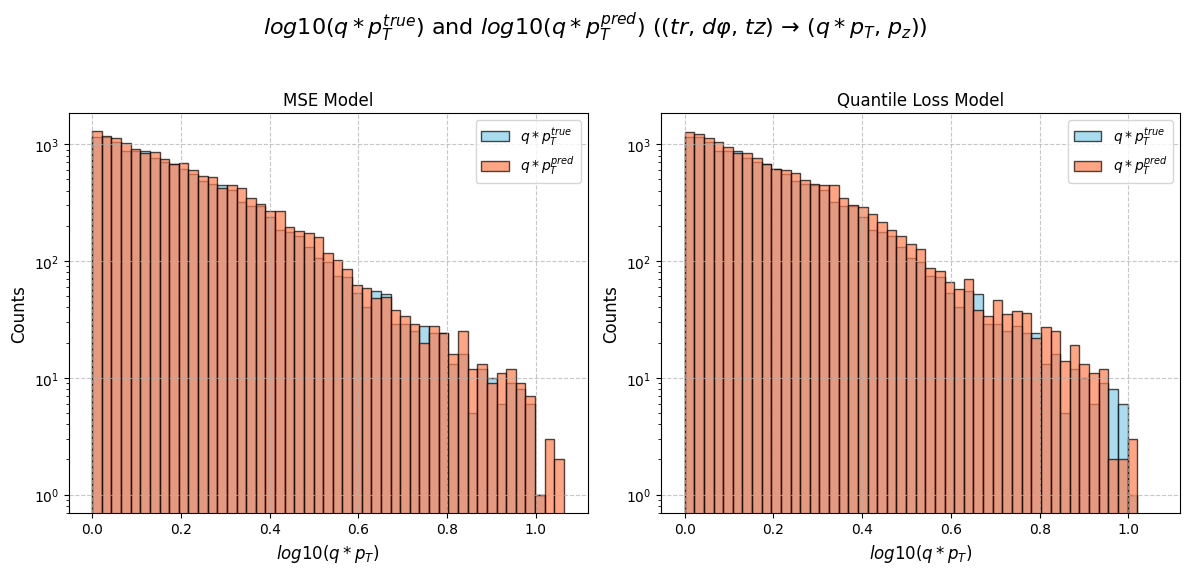

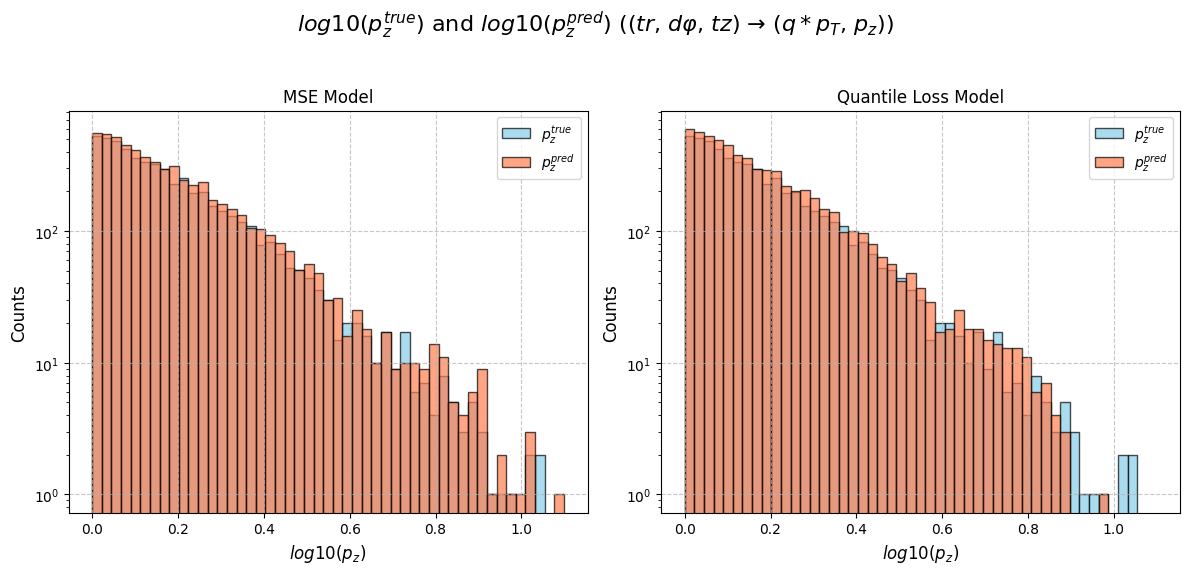

In [ ]:
def plot_log10_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"$log10({var}^{{true}})$ and $log10({var}^{{pred}})$"
        title += title_suffix

        xlabel = f"$log10({var})$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        filename = f"log10_{variable_filenames[var]}_true_and_log10_{variable_filenames[var]}_pred.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            0,
            max(
                max(np.log10(pi_true_values)),
                max(np.log10(pi_pred_mse_list)),
                max(np.log10(pi_pred_qloss_list)),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_mse_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_qloss_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_log10_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

In [ ]:
import torch.nn.functional as F
from sklearn.utils import resample
from scipy.stats import bootstrap


def evaluate_models():
    # Initialize lists to store the MAE values
    m_transf_mae_pt = []
    m_transf_mae_pz = []
    q_transf_mae_pt = []
    q_transf_mae_pz = []

    pt_conf_mae_list = []
    batch_limit = 10
    epochs = 1
    for epoch in tqdm(range(epochs)):
        with torch.no_grad():
            for i, (input, mask, target) in enumerate(tqdm(tl)):
                if i >= batch_limit:
                    break
                # Transformer MSE
                pred1 = transf_mse_model(input, mask=mask)
                pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
                pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

                m_transf_mae_pt.append(pt_mae1.item())
                m_transf_mae_pz.append(pz_mae1.item())

                # Transformer Qloss
                pred2 = qloss_transf_tt_model(input, mask=mask)
                pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
                pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

                q_transf_mae_pt.append(pt_mae2.item())
                q_transf_mae_pz.append(pz_mae2.item())

                # conformal fitt squares
                # pt_conf_mae = conformal_mae(input, target)
                # pt_conf_mae_list.append(pt_conf_mae.item())

    # Convert lists to numpy arrays
    m_transf_mae_pt = np.array(m_transf_mae_pt)
    q_transf_mae_pt = np.array(q_transf_mae_pt)
    m_transf_mae_pz = np.array(m_transf_mae_pz)
    q_transf_mae_pz = np.array(q_transf_mae_pz)
    # pt_conf_mae_list = np.array(pt_conf_mae_list)

    def calculate_ci(data, confidence=0.95, n_resamples=1000):
        res = bootstrap(
            (data,),
            np.mean,
            confidence_level=confidence,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42,
        )
        mean = np.mean(data)
        ci_lower = res.confidence_interval.low
        ci_upper = res.confidence_interval.high
        delta = (ci_upper - mean) / 2
        return mean, delta

    # confidence intervals
    transf_mse_pt_mean, transf_mse_pt_delta = calculate_ci(m_transf_mae_pt)
    transf_q_pt_mean, transf_q_pt_delta = calculate_ci(q_transf_mae_pt)
    transf_mse_pz_mean, transf_mse_pz_delta = calculate_ci(m_transf_mae_pz)
    transf_q_pz_mean, transf_q_pz_delta = calculate_ci(q_transf_mae_pz)
    # pt_conf_mean, pt_conf_delta = calculate_ci(pt_conf_mae_list)

    print(
        f"Transformer MSE PT MAE: {transf_mse_pt_mean:.4f} ± {transf_mse_pt_delta:.4f}"
    )
    print(f"Transformer Qloss PT MAE: {transf_q_pt_mean:.4f} ± {transf_q_pt_delta:.4f}")
    print(
        f"Transformer MSE PZ MAE: {transf_mse_pz_mean:.4f} ± {transf_mse_pz_delta:.4f}"
    )
    print(f"Transformer Qloss PZ MAE: {transf_q_pz_mean:.4f} ± {transf_q_pz_delta:.4f}")
    # print(f"Conformal MAE: {pt_conf_mean:.4f} ± {pt_conf_delta:.4f}")

    # Save the results to a file
    results = {}
    results["p_T"] = {
        "mse": (transf_mse_pt_mean, transf_mse_pt_delta),
        "qloss": (transf_q_pt_mean, transf_q_pt_delta),
    }
    results["p_z"] = {
        "mse": (transf_mse_pz_mean, transf_mse_pz_delta),
        "qloss": (transf_q_pz_mean, transf_q_pz_delta),
    }
    # results["conformal"] = (pt_conf_mean, pt_conf_delta)

    with open(output_dir / "mae_results.json", "w") as f:
        json.dump(results, f)


evaluate_models()

  0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Transformer MSE PT MAE: 0.1340 ± 0.0394
Transformer Qloss PT MAE: 0.0791 ± 0.0203
Transformer MSE PZ MAE: 0.1096 ± 0.0328
Transformer Qloss PZ MAE: 0.0519 ± 0.0140


Transformer MSE PT MAE: 0.4409 ± 0.1944
Transformer Qloss PT MAE: 0.1949 ± 0.0778
Transformer MSE PZ MAE: 1.3537 ± 0.5189
Transformer Qloss PZ MAE: 0.7749 ± 0.2834

Transformer MSE PT MAE: 0.5884 ± 0.2166
Transformer Qloss PT MAE: 0.1474 ± 0.0739
Transformer MSE PZ MAE: 1.3716 ± 0.3525
Transformer Qloss PZ MAE: 0.6085 ± 0.1636

Transformer MSE PT MAE: 0.0869 ± 0.0125

Transformer Qloss PT MAE: 0.0959 ± 0.0147

Transformer MSE PZ MAE: 0.0543 ± 0.0083

Transformer Qloss PZ MAE: 0.0512 ± 0.0085

In [13]:
from tbparse import SummaryReader


def plot_tensorboard(log_dir: Path, model_name: str):
    log_name = log_dir.name + "_" + model_name

    reader = SummaryReader(log_dir, extra_columns={"dir_name"}, pivot=False)
    # reader = SummaryReader(log_dir)
    df = reader.scalars
    print(df)

    df["unique_tag"] = df["dir_name"] + "/" + df["tag"]

    # Get the unique tags
    unique_tags = df["tag"].unique()

    print(unique_tags)

    # Extract values for each tag
    unique_tags_dfs = {}
    for tag in unique_tags:
        unique_tags_dfs[tag] = df[df["tag"] == tag].reset_index(drop=True)

        print(unique_tags_dfs[tag])

    for tag in unique_tags:
        # if not "loss" in unique_tags_dfs[tag]
        plt.figure()
        for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
            dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

            dir_df = unique_tags_dfs[tag][dir_name_sel]
            # Group by step and take the mean and std
            dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
            # dir_df.columns = dir_df.columns.droplevel(0)
            dir_df.reset_index(inplace=True)
            plt.errorbar(
                x=dir_df["step"],
                y=dir_df["value"]["mean"],
                label=dir_name,
                alpha=0.7,
                yerr=dir_df["value"]["std"],
            )
        # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
        # plt.title(tag)
        plt.xlabel("Step")
        plt.ylabel(tag.capitalize())
        plt.legend()
        plt.grid(True)
        title = f"{model_name} {tag}"
        title += title_suffix
        plt.title(title)
        plt.savefig(output_dir / (tag + "_" + log_name + ".png"), format="png")

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    title = f"{model_name} {tag}"
    title += title_suffix
    plt.title(title)
    plt.savefig(output_dir / ("loss_log_" + log_name + ".png"), format="png")
    plt.show()

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    title = f"{model_name} {tag}"
    title += title_suffix
    plt.title(title)
    plt.savefig(output_dir / ("loss_log_log_" + log_name + ".png"), format="png")
    plt.show()

2025-03-03 11:52:27.286139: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 11:52:27.313836: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.006106  loss_val
130698  61500      loss  0.002739  loss_val
130699  61500      loss  0.003647  loss_val
130700  61500      loss  0.002778  loss_val
130701  61500      loss  0.002521  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

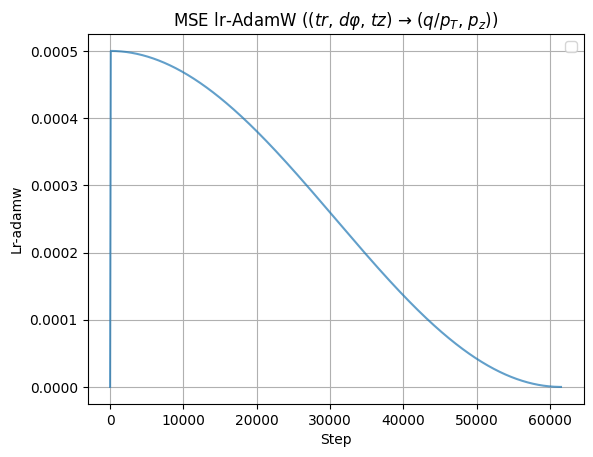

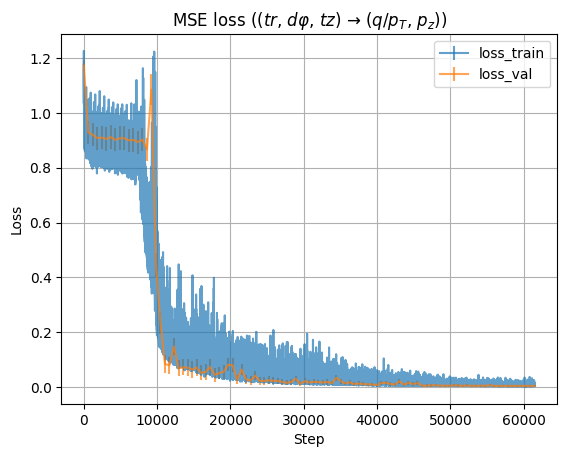

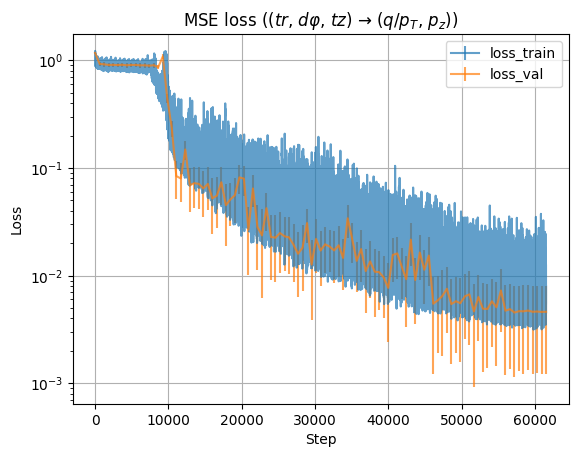

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


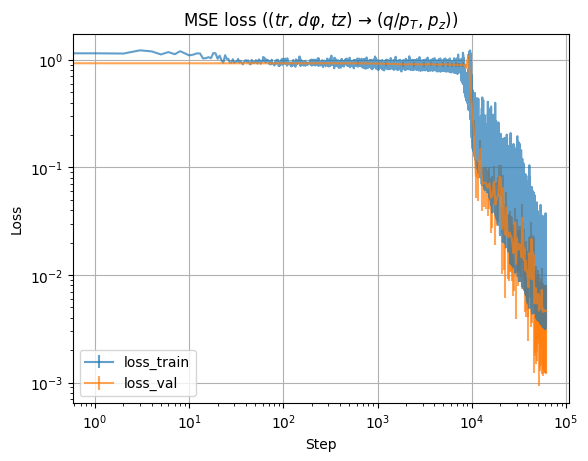

         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.020743  loss_val
130698  61500      loss  0.018409  loss_val
130699  61500      loss  0.019451  loss_val
130700  61500      loss  0.018525  loss_val
130701  61500      loss  0.018288  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

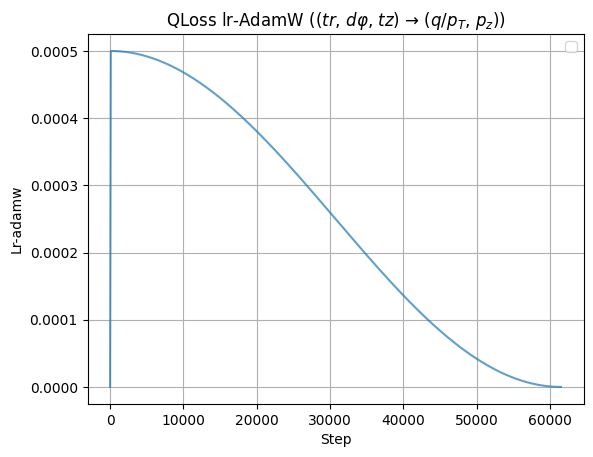

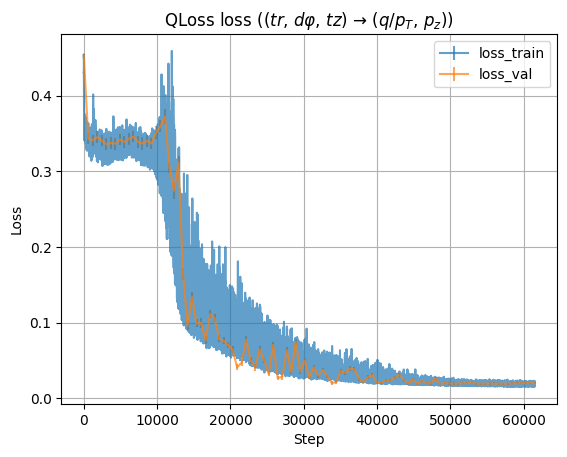

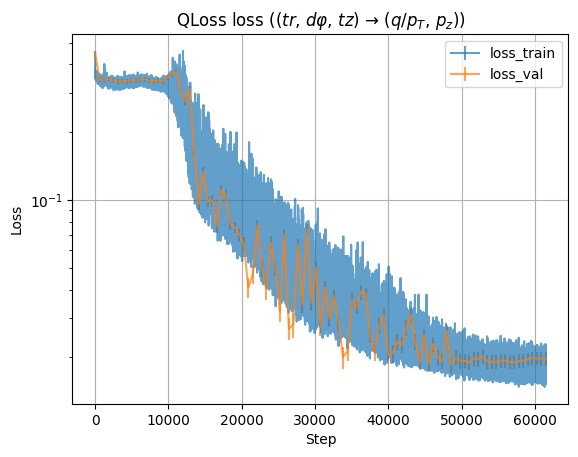

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


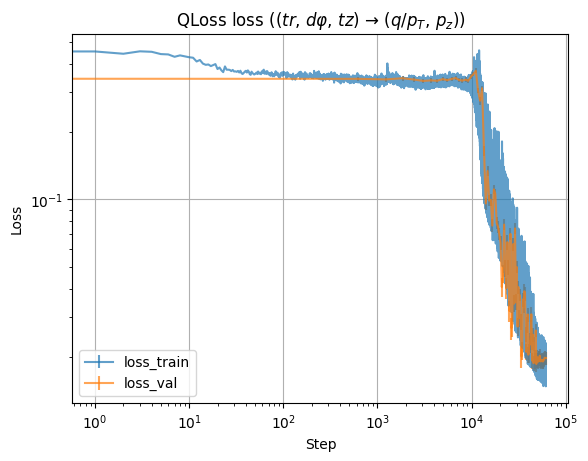

         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.007121  loss_val
130698  61500      loss  0.004108  loss_val
130699  61500      loss  0.004909  loss_val
130700  61500      loss  0.003833  loss_val
130701  61500      loss  0.003579  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

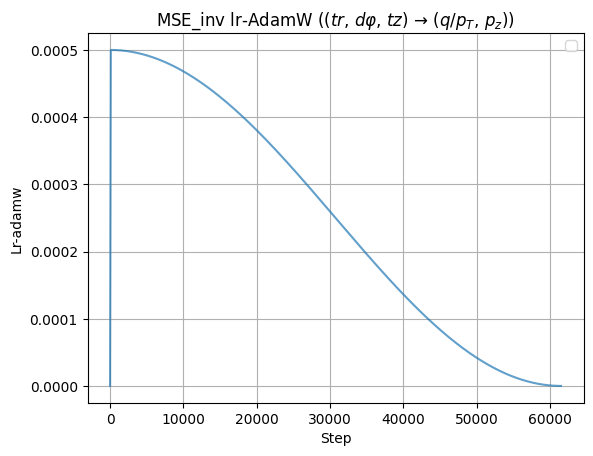

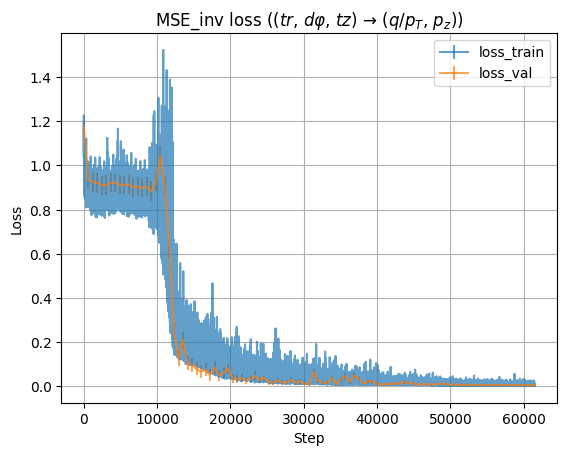

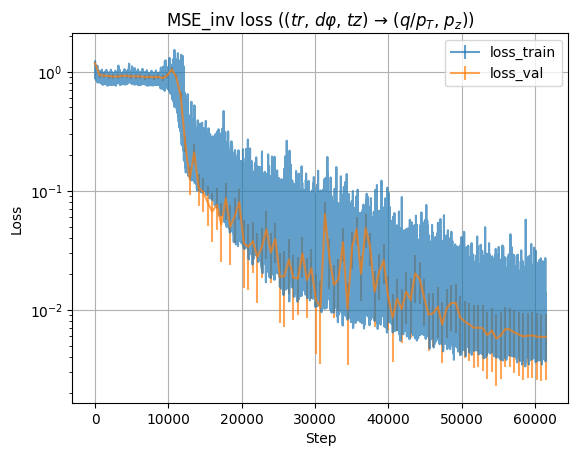

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


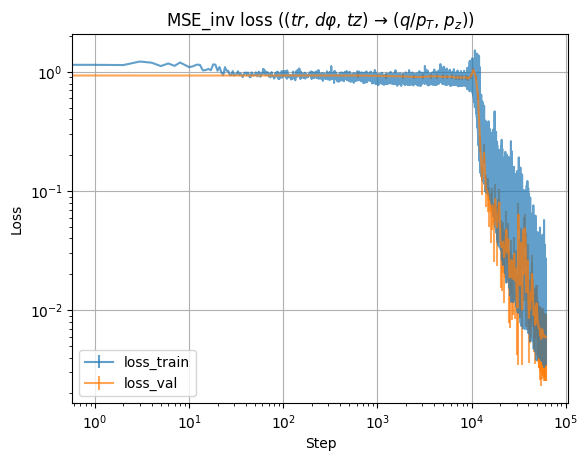

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_name in models_dir:
    log_dir = models_dir[model_name]
    plot_tensorboard(log_dir, model_name=model_name)

In [ ]:
batch_limit = 10
epochs = 1
attention_sum_mse = []
for epoch in tqdm(range(epochs)):
    with torch.no_grad():
        for i, (input, _, target) in enumerate(tqdm(tl)):
            if i >= batch_limit:
                break
            # Transformer MSE
            # Output shape: (n_layers, batch_size, n_heads, seq_len, seq_len)
            pred1 = transf_mse_model.get_attention_maps(input)
            # print(pred1.shape)
            # print(pred1)
            print(pred1[0].shape)
            # pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
            # pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

            # m_transf_mae_pt.append(pt_mae1.item())
            # m_transf_mae_pz.append(pz_mae1.item())

            # Add the attention maps to the attention_sum
            if len(attention_sum_mse) == 0:
                # Initialize the attention_sum to zeros with shape torch.Size([32, 4, 18, 18])
                # attention_sum_mse = [torch.zeros']

                attention_sum_mse = [torch.zeros_like(att) for att in pred1]
            for j, att in enumerate(pred1):
                attention_sum_mse[j] += att

            # Transformer Qloss
            pred2 = qloss_transf_tt_model.get_attention_maps(input)
            # print(pred2.shape)
            # print(pred2)
            # pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
            # pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

            # q_transf_mae_pt.append(pt_mae2.item())
            # q_transf_mae_pz.append(pz_mae2.item())

            # conformal fitt squares
            # pt_conf_mae = conformal_mae(input, target)
            # pt_conf_mae_list.append(pt_conf_mae.item())

In [ ]:
# Plot the attention maps
plt.figure(figsize=(12, 6))
plt.suptitle("Attention Maps", fontsize=16)

pred1 = attention_sum_mse

# MSE Model
for layer in range(len(pred1)):
    for i in range(pred1[0].shape[1]):
        plt.subplot(len(pred1), pred1[0].shape[1], layer * pred1[0].shape[1] + i + 1)
        # Plot the head with matplotlib
        # Do a mean over the batch size
        mean_attention = pred1[layer].mean(dim=0)[i].numpy()
        print(pred1[layer].mean(dim=0).shape)
        plt.imshow(mean_attention, cmap="viridis", origin="lower")
        # Add the colorbar
        plt.colorbar()
        plt.title(f"Layer {layer}, Head {i}")
plt.title("MSE Model")

# # Qloss
# plt.subplot(1, 2, 2)
# # Plot the first
# plt.imshow(pred2[0][0, 0].numpy(), cmap="viridis", origin="lower")
# plt.title("Quantile Loss Model")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [43]:
all_inputs = []
all_targets = []
all_input_masks = []
batch_limit = 10
for i, (input, masks, target) in enumerate(tqdm(tl)):
    # Reshape the input and target to shape (n_features, batch_size, seq_len)
    input = input.permute(2, 0, 1)
    target = target.permute(1, 0)

    all_inputs.append(input)
    all_targets.append(target)
    all_input_masks.append(masks)
    if i >= batch_limit:
        break

0it [00:00, ?it/s]

In [44]:
# print(all_inputs[0][0])

In [45]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 5408])
torch.Size([2, 352])
torch.Size([5408])


In [46]:
# # Print input and mask side by side
# for i in range(all_inputs.shape[1]):
#     print(all_inputs[:, i], all_input_masks[i])
#     if i == 100:
#         break

In [47]:
# Keep input only where mask is True
all_inputs = all_inputs[:, all_input_masks]
print(all_inputs.shape)

torch.Size([3, 4074])


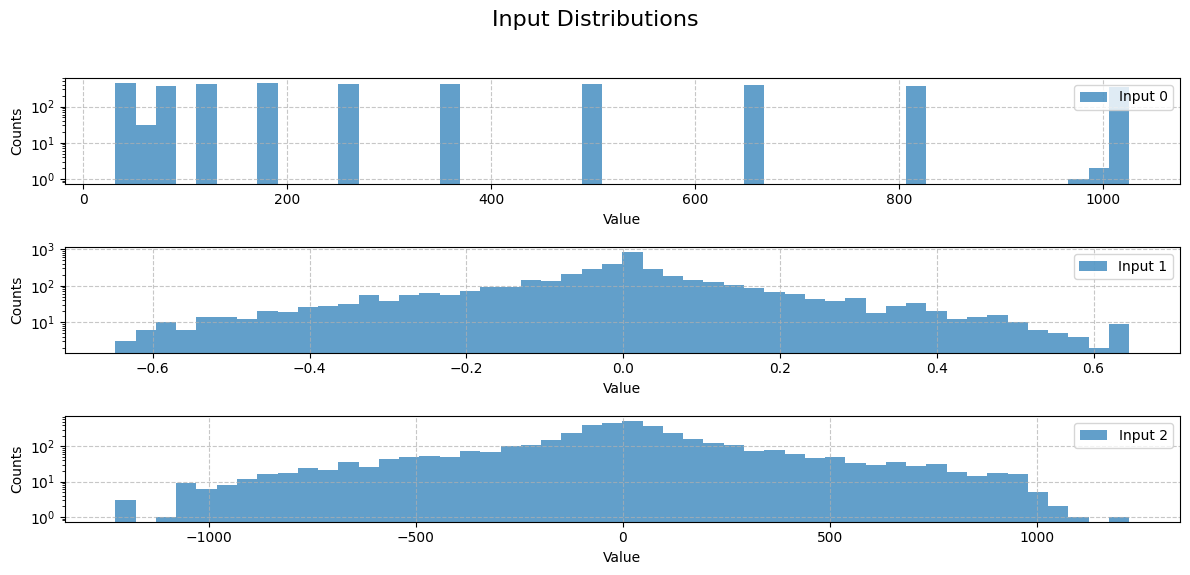

In [48]:
# Plot the distribution of the inputs
plt.figure(figsize=(12, 6))
plt.suptitle("Input Distributions", fontsize=16)

# Plot the inputs
for i in range(all_inputs.shape[0]):
    plt.subplot(all_inputs.shape[0], 1, i + 1)
    plt.hist(all_inputs[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Input {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "input_distributions.png", format="png")
plt.show()

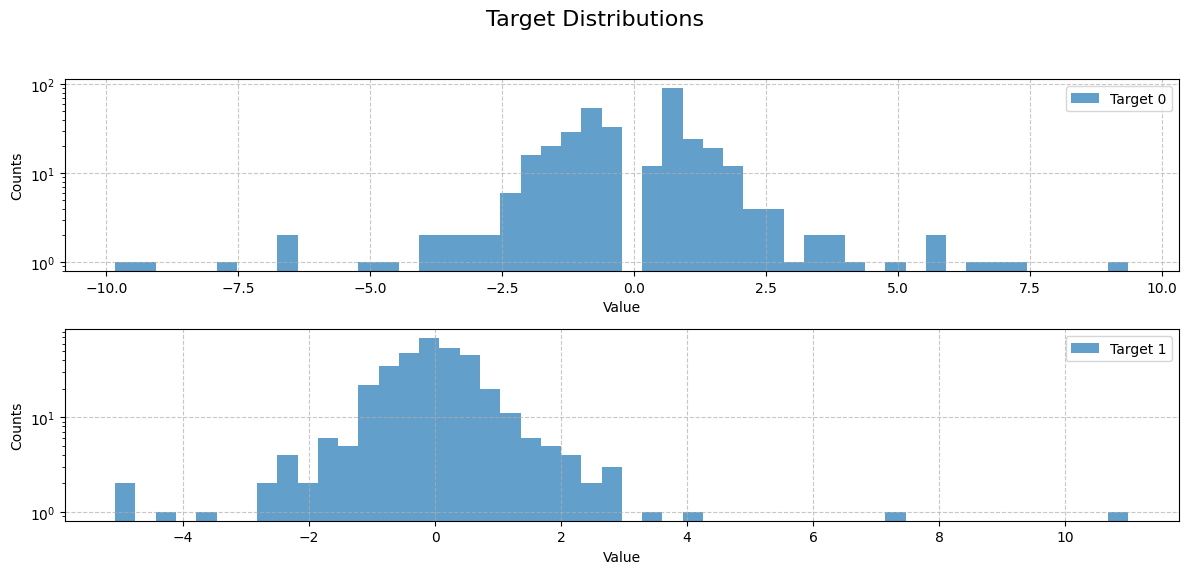

In [49]:
# Plot the distribution of the targets
plt.figure(figsize=(12, 6))
plt.suptitle("Target Distributions", fontsize=16)

# Plot the targets
for i in range(all_targets.shape[0]):
    plt.subplot(all_targets.shape[0], 1, i + 1)
    plt.hist(all_targets[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Target {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "target_distributions.png", format="png")
plt.show()